<a href="https://colab.research.google.com/github/michael83988/Taiwan_Stock_Analysis/blob/2025-01-04-From-TWSE/Taiwan_Stock_Anaylsis_Real_Time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install playwright

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 MB 17.9 MB/s eta 0:00:00


In [2]:
!playwright install firefox

87.6 MiB [] 0% 0.0s87.6 MiB [] 0% 24.6s87.6 MiB [] 0% 10.8s87.6 MiB [] 0% 10.3s87.6 MiB [] 1% 8.1s87.6 MiB [] 1% 6.0s87.6 MiB [] 2% 4.9s87.6 MiB [] 3% 4.2s87.6 MiB [] 4% 3.5s87.6 MiB [] 5% 3.2s87.6 MiB [] 6% 3.1s87.6 MiB [] 6% 3.0s87.6 MiB [] 7% 2.7s87.6 MiB [] 8% 2.6s87.6 MiB [] 10% 2.4s87.6 MiB [] 11% 2.3s87.6 MiB [] 12% 2.2s87.6 MiB [] 12% 2.3s87.6 MiB [] 13% 2.4s87.6 MiB [] 14% 2.3s87.6 MiB [] 15% 2.2s87.6 MiB [] 16% 2.1s87.6 MiB [] 17% 2.1s87.6 MiB [] 19% 2.0s87.6 MiB [] 20% 2.0s87.6 MiB [] 21% 2.0s87.6 MiB [] 22% 1.9s87.6 MiB [] 23% 1.9s87.6 MiB [] 24% 1.9s87.6 MiB [] 25% 1.8s87.6 MiB [] 26% 1.8s87.6 MiB [] 27% 1.8s87.6 MiB [] 28% 1.7s87.6 MiB [] 29% 1.7s87.6 MiB [] 30% 1.6s87.6 MiB [] 31% 1.6s87.6 MiB [] 33% 1.6s87.6 MiB [] 34% 1.5s87.6 MiB [] 35% 1.5s87.6 MiB [] 36% 1.4s87.6 MiB [] 37% 1.4s87.6 MiB [] 38% 1.4s87.6 MiB [] 39% 1.4s87.6 MiB [] 40% 1.4s87.6 MiB [] 41% 1.4s87.6 MiB [] 42% 1.3s87.6 MiB [] 43% 1.3s87.6 MiB [] 44% 1.3s87.6 MiB [] 45% 1.3s87.6 MiB [] 46% 1.3s87.6 MiB []

In [3]:
#用指令來下載ttf檔(字型檔)
!wget -O taipei_sans_tc_beta.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

--2025-01-04 01:53:51--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 173.194.217.100, 173.194.217.138, 173.194.217.102, ...
Connecting to drive.google.com (drive.google.com)|173.194.217.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-01-04 01:53:51--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.210.132, 2607:f8b0:400c:c0f::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.210.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘taipei_sans_tc_beta.ttf’

taipei_sans_tc_beta 100%[===================>]  19.70M  47.9MB/s    in 0.4s    

2025-01-04 01:53

## 匯入packages

In [4]:
from playwright.async_api import async_playwright, Page, expect, Locator, BrowserContext
import re
import numpy as np
from bs4 import BeautifulSoup as BS
import asyncio
from matplotlib import pyplot as plt
from matplotlib.font_manager import fontManager
import matplotlib as mpl

## 全域變數定義

In [5]:
stock_number='2884'
financial_reports=[]
financial_data=[]
process_num=9  # 實際要處理的季數量需再+1，為了處理財報中按年累加的項目(ex: 損益表Q4，現金流量表Q2~Q4)
offset=0  # 測試用；從第幾個財報開始蒐集；正式情況下為0

## 中文相關設定

In [6]:
# 新增字型檔
fontManager.addfont('taipei_sans_tc_beta.ttf')

# 顯示現有的字型檔
a = sorted([f.name for f in mpl.font_manager.fontManager.ttflist])
#mpl.use('Agg')
for i in a:
  print(i)

# matplotlib設定預設的字型檔
mpl.rc('font', family='Taipei Sans TC Beta')

DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif Display
Humor Sans
Liberation Mono
Liberation Mono
Liberation Mono
Liberation Mono
Liberation Sans
Liberation Sans
Liberation Sans
Liberation Sans
Liberation Sans Narrow
Liberation Sans Narrow
Liberation Sans Narrow
Liberation Sans Narrow
Liberation Serif
Liberation Serif
Liberation Serif
Liberation Serif
STIXGeneral
STIXGeneral
STIXGeneral
STIXGeneral
STIXNonUnicode
STIXNonUnicode
STIXNonUnicode
STIXNonUnicode
STIXSizeFiveSym
STIXSizeFourSym
STIXSizeFourSym
STIXSizeOneSym
STIXSizeOneSym
STIXSizeThreeSym
STIXSizeThreeSym
STIXSizeTwoSym
STIXSizeTwoSym
Taipei Sans TC Beta
cmb10
cmex10
cmmi10
cmr10
cmss10
cmsy10
cmtt10


## 函數定義

In [16]:
# Plotting function
# Like "American Stock Analysis", plotting results shall depend on company whether it has inventories or not
def plot_results(financial_data_list:list):
  print(f'Start plotting financial indicators of {financial_data_list[0]["Company"]}\t')

  # Reverse financial list
  financial_data_list.reverse()

  # Company;s name
  company_name=financial_data_list[0]["Company"]

  # Check company's inventories
  inv=True if "Inventories" in financial_data_list[0] else False

  # Get x-label (year+quarter) info
  x=[d["Quarter"] for d in financial_data_list]
  x_temp=np.arange(len(x)) # For substituting x-label

  # Company with inventories
  if inv:
    # Figure 1: Liabilities and stockholder's equity, stacked barchart (liabilities + equity = assets)
    fig1=plt.subplot(111)

    Liabilities=[d["Liabilities"] for d in financial_data_list]
    Equity=[d["Equity"] for d in financial_data_list]

    plt.bar(x_temp,Liabilities,color="blue",width=0.5,label="Liabilities")
    plt.bar(x_temp,Equity,color="green",width=0.5,label="Equity",bottom=Liabilities)
    plt.title(f"{company_name}\nLiabilities and Equity",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("NTD")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 2: Cash flow, stacked barchart
    fig2=plt.subplot(111)

    Operating=[d["CashFlowsFromUsedInOperatingActivities"] for d in financial_data_list]
    Investing=[d["NetCashFlowsFromUsedInInvestingActivities"] for d in financial_data_list]
    Financing=[d["CashFlowsFromUsedInFinancingActivities"] for d in financial_data_list]

    plt.bar(x_temp,Operating,color="blue",label="Net cash flow from\noperating activities",width=0.5)

    # Stack upward (positive) or downward (negative) based on the sign of value
    # Two baselines for recording positive and negative values of cash flows
    baseline_positive=[]
    baseline_negative=[]

    for o in Operating:
      if o>=0:
        baseline_positive.append(o)
        baseline_negative.append(0)
      else:
        baseline_positive.append(0)
        baseline_negative.append(o)

    baseline_for_investing=[baseline_positive[idx] if i>=0 else baseline_negative[idx] for idx,i in enumerate(Investing)]
    plt.bar(x_temp,Investing,color="green",label="Net cash flow from\ninvesting activities",width=0.5,bottom=baseline_for_investing)

    for idx,i in enumerate(Investing):
      if i>=0:
        baseline_positive[idx]+=i
      else:
        baseline_negative[idx]+=i

    baseline_for_financing=[baseline_positive[idx] if f>=0 else baseline_negative[idx] for idx,f in enumerate(Financing)]
    plt.bar(x_temp,Financing,color="gray",label="Net cash flow from\nfinancing activities",width=0.5,bottom=baseline_for_financing)

    plt.title(f"{company_name}\nCash flows",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("NTD")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 3: Operating circumstances
    fig3=plt.subplot(111)
    plt.xticks(rotation=45)  # Need to place this setting before plotting or interpreter will confuse

    Revenue=[d["Revenue"] for d in financial_data_list]
    GrossProfit=[d["GrossProfit"] for d in financial_data_list]
    ProfitLoss=[d["ProfitLoss"] for d in financial_data_list]
    ComprehensiveIncome=[d["ComprehensiveIncome"] for d in financial_data_list]
    OtherIncome=np.array(ComprehensiveIncome)-np.array(ProfitLoss)
    DaysSalesOfInventories=[d["DaysSalesOfInventories"] for d in financial_data_list]

    br1=plt.bar(x_temp-0.3,Revenue,color="blue",label="Revenue",width=0.6,alpha=0.85)
    br2=plt.bar(x_temp-0.2,GrossProfit,color="green",label="Gross profit",width=0.6,alpha=0.85)
    br3=plt.bar(x_temp-0.1,ProfitLoss,color="orange",label="Profit loss",width=0.6,alpha=0.85)
    br4=plt.bar(x_temp+0.2,OtherIncome,color="brown",label="Other income",width=0.6,alpha=0.85,zorder=1)

    # Double y-axis
    fig3_1=fig3.twinx()
    ln1=fig3_1.plot(x_temp,DaysSalesOfInventories,color="red",marker="D",label="Days sales of inventories")

    plt.xticks(x_temp,x)
    plt.title(f"{company_name}\nOperating circumstances",fontsize=18)
    fig3.set_ylabel("NTD")
    fig3_1.set_ylabel("Days")
    brs_lns=[br1,br2,br3,br4]+(ln1)
    plt.legend(handles = brs_lns, bbox_to_anchor=(1.2,0.7), loc='upper left')
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 4: Competitiveness
    GrossMargin=[d["GrossMargin"] for d in financial_data_list]
    OperatingMargin=[d["OperatingMargin"] for d in financial_data_list]
    ProfitLossMargin=[d["ProfitLossMargin"] for d in financial_data_list]

    fig4=plt.subplot(111)
    fig4.plot(x_temp,GrossMargin,color="blue",marker="o",label="Gross margin(%)")
    fig4.plot(x_temp,OperatingMargin,color="green",marker="o",label="Operating margin(%)")
    fig4.plot(x_temp,ProfitLossMargin,color="orange",marker="o",label="Profitloss margin(%)")

    plt.title(f"{company_name}\nCompetitiveness",fontsize=18)
    plt.ylabel("%")
    plt.xticks(x_temp,x)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.02,0.7), loc='upper left')
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 5: Investment return
    fig5=plt.subplot(111)
    plt.xticks(rotation=45)

    BasicEarningsLossPerShare=[d["BasicEarningsLossPerShare"] for d in financial_data_list]
    DilutedEarningsLossPerShare=[d["DilutedEarningsLossPerShare"] for d in financial_data_list]
    ROA=[d["ROA"] for d in financial_data_list]
    ROE=[d["ROE"] for d in financial_data_list]

    ln1=plt.plot(x_temp,BasicEarningsLossPerShare,color="blue",marker="D",label="Earning per share\n(basic)")
    ln2=plt.plot(x_temp,DilutedEarningsLossPerShare,color="green",marker="D",label="Earning per share\n(diluted)")

    fig5_1=fig5.twinx()
    ln3=fig5_1.plot(x_temp,ROA,color="orange",marker="D",label="Return on assets")
    ln4=fig5_1.plot(x_temp,ROE,color="brown",marker="D",label="Return on equity")

    plt.xticks(x_temp,x)
    plt.title(f"{company_name}\nInvestment return",fontsize=18)
    fig5.set_ylabel("EPS (NTD)")
    fig5_1.set_ylabel("Return (%)")
    lns=ln1+ln2+ln3+ln4
    plt.legend(handles=lns,bbox_to_anchor=(1.2,0.7), loc='upper left')
    plt.grid(axis="y")
    plt.show()

  # Company without inventories
  else:
    # Figure 1: Liabilities and stockholder's equity, stacked barchart (liabilities + equity = assets)
    fig1=plt.subplot(111)

    Liabilities=[d["Liabilities"] for d in financial_data_list]
    Equity=[d["Equity"] for d in financial_data_list]
    TotalInvestment=[d["TotalInvestment"] for d in financial_data_list]
    RiskWeightedAssets=[d["RiskWeightedAssets"] for d in financial_data_list]

    plt.bar(x_temp-0.2,Liabilities,color="blue",width=0.5,label="Liabilities")
    plt.bar(x_temp-0.2,Equity,color="green",width=0.5,label="Equity",bottom=Liabilities)
    plt.bar(x_temp,TotalInvestment,color="orange",width=0.5,label="Total investment")
    plt.bar(x_temp,RiskWeightedAssets,color="red",width=0.5,label="Risk weighted assets")

    plt.title(f"{company_name}\nLiabilities and Equity",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("NTD")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 2: Cash flow, stacked barchart
    fig2=plt.subplot(111)

    Operating=[d["CashFlowsFromUsedInOperatingActivities"] for d in financial_data_list]
    Investing=[d["NetCashFlowsFromUsedInInvestingActivities"] for d in financial_data_list]
    Financing=[d["CashFlowsFromUsedInFinancingActivities"] for d in financial_data_list]

    plt.bar(x_temp,Operating,color="blue",label="Net cash flow from\noperating activities",width=0.5)

    # Stack upward (positive) or downward (negative) based on the sign of value
    # Two baselines for recording positive and negative values of cash flows
    baseline_positive=[]
    baseline_negative=[]

    for o in Operating:
      if o>=0:
        baseline_positive.append(o)
        baseline_negative.append(0)
      else:
        baseline_positive.append(0)
        baseline_negative.append(o)

    baseline_for_investing=[baseline_positive[idx] if i>=0 else baseline_negative[idx] for idx,i in enumerate(Investing)]
    plt.bar(x_temp,Investing,color="green",label="Net cash flow from\ninvesting activities",width=0.5,bottom=baseline_for_investing)

    for idx,i in enumerate(Investing):
      if i>=0:
        baseline_positive[idx]+=i
      else:
        baseline_negative[idx]+=i

    baseline_for_financing=[baseline_positive[idx] if f>=0 else baseline_negative[idx] for idx,f in enumerate(Financing)]
    plt.bar(x_temp,Financing,color="gray",label="Net cash flow from\nfinancing activities",width=0.5,bottom=baseline_for_financing)

    plt.title(f"{company_name}\nCash flows",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("NTD")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 3: Operating circumstances
    fig3=plt.subplot(111)
    plt.xticks(rotation=45)
    plt.grid(axis="y")

    NetIncomeLoss=[d["NetIncomeLoss"] for d in financial_data_list]
    GrossProfit=[d["GrossProfit"] for d in financial_data_list]
    ProfitLoss=[d["ProfitLoss"] for d in financial_data_list]
    ComprehensiveIncome=[d["ComprehensiveIncome"] for d in financial_data_list]
    OtherIncome=np.array(ComprehensiveIncome)-np.array(ProfitLoss)
    NonPerformingLoansRatio=[d["NonPerformingLoansRatio"] for d in financial_data_list]
    CapitalAdequacyRatio=[d["CapitalAdequacyRatio"] for d in financial_data_list]
    CoverageRatio=[d["CoverageRatio"] for d in financial_data_list]

    br1=plt.bar(x_temp-0.2,NetIncomeLoss,color="blue",label="Net income loss",width=0.6)
    br2=plt.bar(x_temp-0.1,GrossProfit,color="green",label="Gross profit",width=0.6)
    br3=plt.bar(x_temp,ProfitLoss,color="orange",label="Profit loss",width=0.6)
    br4=plt.bar(x_temp+0.2,OtherIncome,color="brown",label="Other income",width=0.6)

    # Double y-axis
    fig3_1=fig3.twinx()
    ln1=fig3_1.plot(x_temp,NonPerformingLoansRatio,color="red",marker="D",label="Non-performing \nloans ratio")
    ln2=fig3_1.plot(x_temp,CapitalAdequacyRatio,color="purple",marker="D",label="Capital adequacy\nratio")
    ln3=fig3_1.plot(x_temp,CoverageRatio,color="pink",marker="D",label="Coverage ratio")

    plt.xticks(x_temp,x)
    plt.title(f"{company_name}\nOperating circumstances",fontsize=18)
    fig3.set_ylabel("NTD")
    fig3_1.set_ylabel("%")
    brs_lns=[br1,br2,br3,br4]+(ln1)+(ln2)+(ln3)
    plt.legend(handles=brs_lns, bbox_to_anchor=(1.2,0.7), loc='upper left')
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 4: Competitiveness
    fig4=plt.subplot(111)

    GrossMargin=[d["GrossMargin"] for d in financial_data_list]
    OperatingMargin=[d["OperatingMargin"] for d in financial_data_list]
    ProfitLossMargin=[d["ProfitLossMargin"] for d in financial_data_list]

    fig4.plot(x_temp,GrossMargin,color="blue",marker="o",label="Gross margin(%)")
    fig4.plot(x_temp,OperatingMargin,color="green",marker="o",label="Operating margin(%)")
    fig4.plot(x_temp,ProfitLossMargin,color="orange",marker="o",label="Profit loss margin(%)")

    plt.title(f"{company_name}\nCompetitiveness",fontsize=18)
    plt.xticks(rotation=45)
    plt.xticks(x_temp,x)
    plt.ylabel("%")
    plt.legend(bbox_to_anchor=(1.02,0.7),loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.6)
    plt.show()

    # Figure 5: Investment return
    fig5=plt.subplot(111)
    plt.xticks(rotation=45)

    BasicEarningsLossPerShare=[d["BasicEarningsLossPerShare"] for d in financial_data_list]
    DilutedEarningsLossPerShare=[d["DilutedEarningsLossPerShare"] for d in financial_data_list]
    ROA=[d["ROA"] for d in financial_data_list]
    ROE=[d["ROE"] for d in financial_data_list]

    ln1=plt.plot(x_temp,BasicEarningsLossPerShare,color="blue",marker="D",label="Earning per share\n(basic)")
    ln2=plt.plot(x_temp,DilutedEarningsLossPerShare,color="green",marker="D",label="Earning per share\n(diluted)")

    fig5_1=fig5.twinx()
    ln3=fig5_1.plot(x_temp,ROA,color="orange",marker="D",label="Return on assets")
    ln4=fig5_1.plot(x_temp,ROE,color="brown",marker="D",label="Return on equity")

    plt.xticks(x_temp,x)
    plt.title(f"{company_name}\nInvestment return",fontsize=18)
    fig5.set_ylabel("EPS (NTD)")
    fig5_1.set_ylabel("Return (%)")
    lns=ln1+ln2+ln3+ln4
    plt.legend(handles=lns,bbox_to_anchor=(1.2,0.7), loc='upper left')
    plt.grid(axis="y")
    plt.show()

# Check industry type (finance or non-finance)
# Divide by having inventory or not
# True for having inventory, False for not
def check_industry_type(soup:BS):
  # Find balance sheet first
  # Then check if inventory item is in the balance sheet
  balance_sheet_div=soup.find("div",{"id":"BalanceSheet"})
  balance_sheet_table=balance_sheet_div.find_next_sibling("table")
  inventory=balance_sheet_table.find(lambda tag:tag.name=="tr" and any([True if re.search('存貨',c.text) else False for c in tag.contents])) # 判斷錯誤?! string與text的差別：當一個element內有子節點時，string無法確定要回傳哪一個element的文字，因此會回傳None；用text則是element內所有的文字
  print(f"\t是否有存貨？ {'是' if inventory else '否'}")
  return True if inventory else False


# To get specific data from soup object
# Parameters: ifrs-full name (台灣財報格式), soup object, position (第幾個欄位；考量到有累積的數字需處理；預設只找第一個)
# Return: number, scale, (數字的單位；如仟元、元), sign (正負數)
async def get_data(ifrs_name:str, soup:BS, position:int=0,attrs:dict={}):
  # print(f'\t搜尋項目：{ifrs_name}')
  pattern=r"^"+ifrs_name+"$"
  data_soup=soup.find("ix:nonfraction", {"name":re.compile(pattern)}|attrs) if position==0 else soup.find_all("ix:nonfraction", {"name":re.compile(pattern)}|attrs)[position]
  # print(f"\t{data_soup}")

  # Check if item is found
  if not data_soup:
    return '-','-',False

  scale=data_soup["scale"]
  negative_sign=data_soup.has_attr("sign")
  number=data_soup.text
  return number, scale, negative_sign

# Transform string type data to numeric data
# Parameter: number, scale, negative_sign
# return float
def transform_to_float(number:str, scale:str, negative_sign:bool):
  # Handle item if not found
  if number=='-':
    return np.nan

  clear_number=float(number.replace(",",""))
  scale_num=int(scale)
  number_true=clear_number * np.power(10,scale_num)
  number_true=number_true if not negative_sign else np.negative(number_true)
  return number_true


# Fetch information from soup object of financial report
# return "dictionary object" containing necessary information
# Record different type of information depends on category of company
# Raw data from financial report website, need to be processed carefully (Need previous quarter's report)
# Target information:
#   For company with inventory:
#     Company, Quarter, Assets, Inventories, Liabilities, Total stockholder's equity, Earning per share basic, Earning per share diluted,
#     Revenue, Gross profit, Profit before tax, Net income, Comprehensive income,
#     Cash flow from operating activities, Cash flow from investing activities, Cash flow from financing activities,
#     Gross margin(%), Operating margin(%), Net income margin(%), Days inventory(day),
#     Return on assets(%), Return on equity(%)
#
#   For company without inventory:
#     Company, Quarter, Assets, Liabilities, Total stockholder's equity, Risk weighted assets(風險加權產；台股財報似乎沒有)
#     Total loan(放款總額), Non-performing loan(逾期放款金額), Allowance(備抵呆帳金額), Total investment(總投資；台股財報似乎沒有),
#     Earning per share basic, Earning per share diluted, Revenue, Gross profit, Profit before tax, Net income (profit loss),
#     Comprehensive income, Cash flow from operating activities, Cash flow from investing activities, Cash flow from financing activities,
#     Gross margin(%), Operating margin(%), Net income margin(%), Non-performing loan ratio(%), Capital adequacy ratio(%),
#     Coverage ratio(%), Return on assets(%), Return on equity(%)
async def fetch_financial_info(tup:tuple, tup_previous:tuple):
  # print(f"Processing {tup[0]}, quarter: {tup[1]}")
  print(f'開始處理財報...')
  inv=check_industry_type(tup[2])
  result_dict=dict()  # To contain information of financial report
  result_dict["Company"]=tup[0]
  result_dict["Quarter"]=tup[1]
  print(f"\t同時輸入的財報：{tup[1]}與{tup_previous[1]}")

  # Extract year and quarter from report for necessary calculation
  cur_year_quarter=re.search(r"(\d+)Q(\d+)",tup[1])
  cur_year=cur_year_quarter.groups()[0]
  cur_quarter=cur_year_quarter.groups()[1]
  prev_year_quarter=re.search(r"(\d+)Q(\d+)",tup_previous[1])
  prev_year=prev_year_quarter.groups()[0]
  prev_quarter=prev_year_quarter.groups()[1]

  # print(f'\tCurrent year: {cur_year}, current quarter: {cur_quarter}')
  # print(f'\tPrevious year: {prev_year}, current quarter: {prev_quarter}')

  # 有存貨的公司
  if inv:
    # 資產負債看的是當季當下的資產/負債
    result_dict["Assets"]=transform_to_float(*await get_data("ifrs-full:Assets",tup[2]))
    result_dict["Inventories"]=transform_to_float(*await get_data("ifrs-full:Inventories",tup[2]))
    result_dict["Liabilities"]=transform_to_float(*await get_data("ifrs-full:Liabilities",tup[2]))
    result_dict["Equity"]=transform_to_float(*await get_data("ifrs-full:Equity",tup[2]))

    # 綜合損益表Q4時會是整個年度的，Q1~Q3則是當季,Q4是整年度 -> 要換算成單季(Q4)
    # Q4的第一項減Q3的第三項(需確認年份是一樣的)
    # EPS好像也可以透過相減取得單季的EPS(https://roo.cash/blog/price-to-earning-ratio-introduction/#:~:text=%E8%80%8C%E3%80%8C%E6%AF%8F%E8%82%A1%E7%9B%88%E9%A4%98%EF%BC%88EPS%EF%BC%89%E3%80%8D%E4%BB%A5%E6%99%82%E9%96%93%E7%AF%84%E5%9C%8D%E6%9C%89%E5%88%86%E7%82%BA%E5%96%AE%E5%AD%A3%E3%80%81%E7%B4%AF%E5%AD%A3%E3%80%81%E8%BF%91%E5%9B%9B%E5%AD%A3%E5%8F%8A%E5%B9%B4%E5%BA%A6%EF%BC%8C%E4%B8%8D%E5%90%8C%E7%9A%84%E6%99%82%E9%96%93%E7%AF%84%E5%9C%8D%E4%B9%9F%E6%9C%83%E5%BD%B1%E9%9F%BF%E6%9C%AC%E7%9B%8A%E6%AF%94%E4%BB%A3%E8%A1%A8%E7%9A%84%E6%84%8F%E7%BE%A9%EF%BC%8C%E6%99%82%E9%96%93%E7%AF%84%E5%9C%8D%E5%A6%82%E4%B8%8B%EF%BC%9A%20%E5%96%AE%E5%AD%A3%20%E6%8C%87%E5%96%AE%E4%B8%80%E5%AD%A3%E5%BA%A6%EF%BC%8C%E5%A6%82%EF%BC%9A1%EF%BC%8F1-3%EF%BC%8F31%E3%80%82%20%E7%B4%AF%E5%AD%A3%20%E6%8C%87%E5%A4%9A%E5%80%8B%E5%AD%A3%E5%BA%A6%EF%BC%88%E4%B8%80%E5%B9%B4%E5%85%A7%EF%BC%89%E7%9A%84%E7%B4%AF%E7%A9%8D%EF%BC%8C%E5%A6%82%E7%AC%AC%E4%B8%80%E5%AD%A3%20EPS%20%E7%82%BA%206.7,%E8%BF%91%E5%9B%9B%E5%AD%A3%20%E8%BF%91%E5%9B%9B%E5%80%8B%E5%AD%A3%E5%BA%A6%E7%B4%AF%E5%8A%A0%EF%BC%88%E4%B8%8D%E9%99%90%E4%B8%80%E5%B9%B4%E5%85%A7%EF%BC%89%EF%BC%8C%E5%89%8D%E5%9B%9B%E5%AD%A3%E7%9A%84%E5%96%AE%E5%AD%A3%20EPS%20%E7%B4%AF%E5%8A%A0%E3%80%82%20%E5%B9%B4%E5%BA%A6%20%E6%8C%87%E4%B8%80%E6%95%B4%E5%B9%B4%E5%9B%9B%E5%80%8B%E5%AD%A3%E5%BA%A6%E7%9A%84%20EPS%20%E7%B4%AF%E5%8A%A0%E3%80%82)
    if cur_year==prev_year and cur_quarter=='4' and prev_quarter=='3':  # Q4為整年度的，需特別處理
      result_dict["BasicEarningsLossPerShare"]=transform_to_float(*await get_data("ifrs-full:BasicEarningsLossPerShare",tup[2]))-transform_to_float(*await get_data("ifrs-full:BasicEarningsLossPerShare",tup_previous[2],2))
      result_dict["DilutedEarningsLossPerShare"]=transform_to_float(*await get_data("ifrs-full:DilutedEarningsLossPerShare",tup[2]))-transform_to_float(*await get_data("ifrs-full:DilutedEarningsLossPerShare",tup_previous[2],2))
      result_dict["Revenue"]=transform_to_float(*await get_data("ifrs-full:Revenue",tup[2]))-transform_to_float(*await get_data("ifrs-full:Revenue",tup_previous[2],2))
      result_dict["GrossProfit"]=transform_to_float(*await get_data("ifrs-full:GrossProfit",tup[2]))-transform_to_float(*await get_data("ifrs-full:GrossProfit",tup_previous[2],2))
      result_dict["ProfitLossBeforeTax"]=transform_to_float(*await get_data("ifrs-full:ProfitLossBeforeTax",tup[2]))-transform_to_float(*await get_data("ifrs-full:ProfitLossBeforeTax",tup_previous[2],2))
      result_dict["ProfitLoss"]=transform_to_float(*await get_data("ifrs-full:ProfitLoss",tup[2]))-transform_to_float(*await get_data("ifrs-full:ProfitLoss",tup_previous[2],2))
      result_dict["ComprehensiveIncome"]=transform_to_float(*await get_data("ifrs-full:ComprehensiveIncome",tup[2]))-transform_to_float(*await get_data("ifrs-full:ComprehensiveIncome",tup_previous[2],2))

    else:  # Q1 ~ Q3的，都是當季的數據
      result_dict["BasicEarningsLossPerShare"]=transform_to_float(*await get_data("ifrs-full:BasicEarningsLossPerShare",tup[2]))
      result_dict["DilutedEarningsLossPerShare"]=transform_to_float(*await get_data("ifrs-full:DilutedEarningsLossPerShare",tup[2]))
      result_dict["Revenue"]=transform_to_float(*await get_data("ifrs-full:Revenue",tup[2]))
      result_dict["GrossProfit"]=transform_to_float(*await get_data("ifrs-full:GrossProfit",tup[2]))
      result_dict["ProfitLossBeforeTax"]=transform_to_float(*await get_data("ifrs-full:ProfitLossBeforeTax",tup[2]))
      result_dict["ProfitLoss"]=transform_to_float(*await get_data("ifrs-full:ProfitLoss",tup[2]))
      result_dict["ComprehensiveIncome"]=transform_to_float(*await get_data("ifrs-full:ComprehensiveIncome",tup[2]))

    # Cashflow Q1~Q4都是按年累積，非當季數據！
    # Q1不用減，Q2~Q4都需要相減
    if cur_quarter!='1' and int(cur_quarter)-int(prev_quarter)==1 and cur_year==prev_year:  # Q2~Q4的
      result_dict["CashFlowsFromUsedInOperatingActivities"]=transform_to_float(*await get_data("ifrs-full:CashFlowsFromUsedInOperatingActivities",tup[2]))-transform_to_float(*await get_data("ifrs-full:CashFlowsFromUsedInOperatingActivities",tup_previous[2]))
      result_dict["NetCashFlowsFromUsedInInvestingActivities"]=transform_to_float(*await get_data("tifrs-SCF:NetCashFlowsFromUsedInInvestingActivities",tup[2]))-transform_to_float(*await get_data("tifrs-SCF:NetCashFlowsFromUsedInInvestingActivities",tup_previous[2])) # 似乎是不同的標籤(tifrs-SCF)
      result_dict["CashFlowsFromUsedInFinancingActivities"]=transform_to_float(*await get_data("tifrs-SCF:CashFlowsFromUsedInFinancingActivities",tup[2]))-transform_to_float(*await get_data("tifrs-SCF:CashFlowsFromUsedInFinancingActivities",tup_previous[2]))  # 似乎是不同的標籤(tifrs-SCF)

    else: # Q1的
      result_dict["CashFlowsFromUsedInOperatingActivities"]=transform_to_float(*await get_data("ifrs-full:CashFlowsFromUsedInOperatingActivities",tup[2]))
      result_dict["NetCashFlowsFromUsedInInvestingActivities"]=transform_to_float(*await get_data("tifrs-SCF:NetCashFlowsFromUsedInInvestingActivities",tup[2]))
      result_dict["CashFlowsFromUsedInFinancingActivities"]=transform_to_float(*await get_data("tifrs-SCF:CashFlowsFromUsedInFinancingActivities",tup[2]))

    # Calculate several important indicator about company's performance
    # Gross margin = Gross profit / Revenue * 100(%)
    result_dict["GrossMargin"]=np.round(result_dict["GrossProfit"]/result_dict["Revenue"]*100,2) if result_dict["Revenue"]!=0 else np.nan

    # Operating margin = ProfitLossBeforeTax / Revenue * 100(%)
    result_dict["OperatingMargin"]=np.round(result_dict["ProfitLossBeforeTax"]/result_dict["Revenue"]*100,2) if result_dict["Revenue"]!=0 else np.nan

    # Profit loss margin (net income margin) = Profit loss / Revenue * 100(%)
    result_dict["ProfitLossMargin"]=np.round(result_dict["ProfitLoss"]/result_dict["Revenue"]*100,2) if result_dict["Revenue"]!=0 else np.nan

    # Days sales of inventory = 365 * Inventories / (Revenue - GrossProfit)
    result_dict["DaysSalesOfInventories"]=np.round(365*result_dict["Inventories"]/(result_dict["Revenue"]-result_dict["GrossProfit"]),2)

    # Return on assets = Profit loss (net income) / Assets * 100(%)
    result_dict["ROA"]=np.round(result_dict["ProfitLoss"]/result_dict["Assets"]*100,2) if result_dict["Assets"]!=0 else np.nan

    # Return on equity = Profit loss (net income) / Equity * 100(%)
    result_dict["ROE"]=np.round(result_dict["ProfitLoss"]/result_dict["Equity"]*100,2) if result_dict["Equity"]!=0 else np.nan

  # 沒有存貨的公司
  else:
    # 資產負債看的是當季當下的資產/負債
    result_dict["Assets"]=transform_to_float(*await get_data("ifrs-full:Assets",tup[2]))
    result_dict["Liabilities"]=transform_to_float(*await get_data("ifrs-full:Liabilities",tup[2]))
    result_dict["Equity"]=transform_to_float(*await get_data("ifrs-full:Equity",tup[2]))
    result_dict["RiskWeightedAssets"]=transform_to_float(*await get_data("ifrs-full:RiskWeightedAssets",tup[2]))

    # 逾期放款表看當季放款相關資訊
    result_dict["GrossLoans"]=transform_to_float(*await get_data("tifrs-notes:GrossLoans",tup[2],attrs={"tupleref":"TL"}))
    result_dict["AmountOfNon-PerformingLoans"]=transform_to_float(*await get_data("tifrs-notes:AmountOfNon-PerformingLoans",tup[2],attrs={"tupleref":"TL"}))
    result_dict["AllowanceForBadDebts-AssetQualityForBankSubsidiaries"]=transform_to_float(*await get_data("tifrs-notes:AllowanceForBadDebts-AssetQualityForBankSubsidiaries",tup[2],attrs={"tupleref":"TL"}))
    result_dict["TotalInvestment"]=transform_to_float(*await get_data("tifrs-notes:TotalInvestment",tup[2]))

    if cur_year==prev_year and cur_quarter=='4' and prev_quarter=='3':  # Q4為整年度的，需特別處理
      result_dict["BasicEarningsLossPerShare"]=transform_to_float(*await get_data("ifrs-full:BasicEarningsLossPerShare",tup[2]))-transform_to_float(*await get_data("ifrs-full:BasicEarningsLossPerShare",tup_previous[2],2))
      result_dict["DilutedEarningsLossPerShare"]=transform_to_float(*await get_data("ifrs-full:DilutedEarningsLossPerShare",tup[2]))-transform_to_float(*await get_data("ifrs-full:DilutedEarningsLossPerShare",tup_previous[2],2))
      result_dict["NetIncomeLoss"]=transform_to_float(*await get_data("tifrs-bsci-fh:NetIncomeLoss",tup[2]))-transform_to_float(*await get_data("tifrs-bsci-fh:NetIncomeLoss",tup_previous[2],2))

      # 需透過計算來取得毛利(理論上金融業不需要賣東西，沒有營業成本，只有營業費用才對)
      # 計算方式：毛利=稅前淨利+營業費用
      # 先取得營業費用與稅前淨利，再行計算
      result_dict["OperatingExpense"]=transform_to_float(*await get_data("ifrs-full:OperatingExpense",tup[2]))-transform_to_float(*await get_data("ifrs-full:OperatingExpense",tup_previous[2],2))
      result_dict["ProfitLossBeforeTax"]=transform_to_float(*await get_data("ifrs-full:ProfitLossBeforeTax",tup[2]))-transform_to_float(*await get_data("ifrs-full:ProfitLossBeforeTax",tup_previous[2],2))
      result_dict["GrossProfit"]=result_dict["ProfitLossBeforeTax"]+result_dict["OperatingExpense"]
      result_dict["ProfitLoss"]=transform_to_float(*await get_data("ifrs-full:ProfitLoss",tup[2]))-transform_to_float(*await get_data("ifrs-full:ProfitLoss",tup_previous[2],2))
      result_dict["ComprehensiveIncome"]=transform_to_float(*await get_data("ifrs-full:ComprehensiveIncome",tup[2]))-transform_to_float(*await get_data("ifrs-full:ComprehensiveIncome",tup_previous[2],2))

    else:  # Q1 ~ Q3的，都是當季的數據
      result_dict["BasicEarningsLossPerShare"]=transform_to_float(*await get_data("ifrs-full:BasicEarningsLossPerShare",tup[2]))
      result_dict["DilutedEarningsLossPerShare"]=transform_to_float(*await get_data("ifrs-full:DilutedEarningsLossPerShare",tup[2]))
      result_dict["NetIncomeLoss"]=transform_to_float(*await get_data("tifrs-bsci-fh:NetIncomeLoss",tup[2]))

      # 需透過計算來取得毛利(理論上金融業不需要賣東西，沒有營業成本，只有營業費用才對)
      # 計算方式：毛利=稅前淨利+營業費用
      # 先取得營業費用與稅前淨利，再行計算
      result_dict["OperatingExpense"]=transform_to_float(*await get_data("ifrs-full:OperatingExpense",tup[2]))
      result_dict["ProfitLossBeforeTax"]=transform_to_float(*await get_data("ifrs-full:ProfitLossBeforeTax",tup[2]))
      result_dict["GrossProfit"]=result_dict["ProfitLossBeforeTax"]+result_dict["OperatingExpense"]
      result_dict["ProfitLoss"]=transform_to_float(*await get_data("ifrs-full:ProfitLoss",tup[2]))
      result_dict["ComprehensiveIncome"]=transform_to_float(*await get_data("ifrs-full:ComprehensiveIncome",tup[2]))

    # Cashflow Q1~Q4都是按年累積，非當季數據！
    # Q1不用減，Q2~Q4都需要相減
    if cur_quarter!='1' and int(cur_quarter)-int(prev_quarter)==1 and cur_year==prev_year:  # Q2~Q4的
      # print(f'當季：{transform_to_float(*await get_data("ifrs-full:CashFlowsFromUsedInOperatingActivities",tup[2]))}, 前一季：{transform_to_float(*await get_data("ifrs-full:CashFlowsFromUsedInOperatingActivities",tup_previous[2]))}')
      result_dict["CashFlowsFromUsedInOperatingActivities"]=transform_to_float(*await get_data("ifrs-full:CashFlowsFromUsedInOperatingActivities",tup[2]))-transform_to_float(*await get_data("ifrs-full:CashFlowsFromUsedInOperatingActivities",tup_previous[2]))
      result_dict["NetCashFlowsFromUsedInInvestingActivities"]=transform_to_float(*await get_data("tifrs-SCF:NetCashFlowsFromUsedInInvestingActivities",tup[2]))-transform_to_float(*await get_data("tifrs-SCF:NetCashFlowsFromUsedInInvestingActivities",tup_previous[2])) # 似乎是不同的標籤(tifrs-SCF)
      result_dict["CashFlowsFromUsedInFinancingActivities"]=transform_to_float(*await get_data("tifrs-SCF:CashFlowsFromUsedInFinancingActivities",tup[2]))-transform_to_float(*await get_data("tifrs-SCF:CashFlowsFromUsedInFinancingActivities",tup_previous[2]))  # 似乎是不同的標籤(tifrs-SCF)

    else: # Q1的
      result_dict["CashFlowsFromUsedInOperatingActivities"]=transform_to_float(*await get_data("ifrs-full:CashFlowsFromUsedInOperatingActivities",tup[2]))
      result_dict["NetCashFlowsFromUsedInInvestingActivities"]=transform_to_float(*await get_data("tifrs-SCF:NetCashFlowsFromUsedInInvestingActivities",tup[2]))
      result_dict["CashFlowsFromUsedInFinancingActivities"]=transform_to_float(*await get_data("tifrs-SCF:CashFlowsFromUsedInFinancingActivities",tup[2]))

    # Calculate several important indicator about company's performance
    # Gross margin = Gross profit / NetIncomeLoss * 100(%)
    result_dict["GrossMargin"]=np.round(result_dict["GrossProfit"]/result_dict["NetIncomeLoss"]*100,2) if result_dict["NetIncomeLoss"]!=0 else np.nan

    # Operating margin = ProfitLossBeforeTax / NetIncomeLoss * 100(%)
    result_dict["OperatingMargin"]=np.round(result_dict["ProfitLossBeforeTax"]/result_dict["NetIncomeLoss"]*100,2) if result_dict["NetIncomeLoss"]!=0 else np.nan

    # Profit loss margin (net income margin) = Profit loss / NetIncomeLoss * 100(%)
    result_dict["ProfitLossMargin"]=np.round(result_dict["ProfitLoss"]/result_dict["NetIncomeLoss"]*100,2) if result_dict["NetIncomeLoss"]!=0 else np.nan

    # Non-performing loans ratio = Non-performing loans / Gross loans * 100(%)
    result_dict["NonPerformingLoansRatio"]=np.round(result_dict["AmountOfNon-PerformingLoans"]/result_dict["GrossLoans"]*100,2) if result_dict["GrossLoans"]!=0 else np.nan

    # Capital adequacy ratio = (Tier 1 capital + tier 2 capital) / Risk weighted assets *100(%) = Equity / Risk weighted assets * 100(%)
    result_dict["CapitalAdequacyRatio"]=np.round(result_dict["Equity"]/result_dict["RiskWeightedAssets"]*100,2) if result_dict["RiskWeightedAssets"]!=0 else np.nan

    # Coverage ratio = AllowanceForBadDebts-AssetQualityForBankSubsidiaries / AmountOfNon-PerformingLoans * 100(%)
    result_dict["CoverageRatio"]=np.round(result_dict["AllowanceForBadDebts-AssetQualityForBankSubsidiaries"]/result_dict["AmountOfNon-PerformingLoans"]*100,2) if result_dict["AmountOfNon-PerformingLoans"]!=0 else np.nan

    # Return on assets = Profit loss (net income) / Assets * 100(%)
    result_dict["ROA"]=np.round(result_dict["ProfitLoss"]/result_dict["Assets"]*100,2) if result_dict["Assets"]!=0 else np.nan

    # Return on equity = Profit loss (net income) / Equity * 100(%)
    result_dict["ROE"]=np.round(result_dict["ProfitLoss"]/result_dict["Equity"]*100,2) if result_dict["Equity"]!=0 else np.nan

  return result_dict



# Retrieve each financial data
# 一個公司搜尋結果只能綁定一個popup window -> 似乎無法一次點開多個季的財報內容?
# 因為財報會隨著點開的季不同而內容改變，因此每一份財報應該要另存成beautifulsoup的檔
async def get_report_as_soup(browser_context:BrowserContext, page:Page, tr:Locator):
  # Click 查詢 to popup new page of financial reports
  global financial_reports
  y_q=await tr.locator('xpath=//td[1]').text_content()
  fetch_button=tr.locator('xpath=//td[3]//input')

  # pop出新頁面之後進行資料獲取。之後必須將焦點回到原本的page上，才能點開下一個內容
  async with browser_context.expect_page() as pop_page_info:
    await fetch_button.click()
  report_page=await pop_page_info.value
  await report_page.wait_for_load_state()
  await report_page.wait_for_timeout(10000)  # 保留讓網頁內容載入的時間
  await report_page.wait_for_load_state()
  company_name_span=report_page.locator('css=div[class="header"]').locator('xpath=//div[2]//span[1]')
  company_name_inner_html=await company_name_span.inner_html()
  print(f'點開{y_q}財報')
  print(f'\t財報標題: {company_name_inner_html}')
  company_name=re.search(r'(.*)<br>',company_name_inner_html).groups()[0]
  content=await report_page.content()
  # print('取得page內容')
  report=BS(content,"html.parser")
  # print('轉換成BS物件')
  financial_reports.append((company_name,y_q,report))  # 將各季財報轉成soup物件並存入global的financial_reports中
  # print('存入list中')
  # print(f'page被關掉了嗎? {page.is_closed()}')
  await report_page.close()  # 必須將popup頁面關掉才能繼續點開下一個(操作page)



# Enter stock number in search box to search
async def search_company(browser_context:BrowserContext,page:Page):
  global financial_reports,financial_data
  search_box=page.locator('css=input[id="co_id"]')
  await expect(search_box).to_be_enabled()
  print('找到輸入框')
  await page.wait_for_timeout(3000)

  print(f'輸入: {stock_number}')
  await search_box.fill(stock_number)
  await page.wait_for_timeout(3000)
  print('開始搜尋')
  await search_box.press('Enter')
  await page.wait_for_timeout(3000)

  # Check search result
  result_div=page.locator('css=div[id="zoom"]')
  no_result=result_div.get_by_text('查無資料')
  if await no_result.count()==1:
    print('查無資料。重新查詢')
    return

  result_list_table=result_div.locator('xpath=//div//div//form[@id="fm1"]//table')
  print(f'搜尋結果table數: {await result_list_table.count()}')
  await page.wait_for_timeout(3000)


  # tr_IFRSs_after=result_list_table.locator('xpath=//tbody//tr').filter(has_text="IFRSs後")
  # tr_IFRSs_before=result_list_table.locator('xpath=//tbody//tr').filter(has_text="IFRSs前")
  # trs=result_list_table.locator('xpath=//tbody//tr[following-sibling::tr[contains(text(),"IFRSs後")]]') #  and preceding-sibling::tr[contains(text(),"IFRSs前")] and class="even|odd"]
  # trs=result_list_table.locator('xpath=//tbody//descendant::tr[contains(text(),"IFRSs後")]')?? 不會用xpath找

  # 計算IFRSs後財報數量
  # 透過xpath語法來判斷
  trs=await result_list_table.locator('xpath=//tbody//tr').all()
  end=0
  for i in range(len(trs)):
    if (await trs[i].filter(has_text="IFRSs前").count())==1:
      end=i
      # print(i)
      break
  trs_wanted=trs[2+offset:end]
  print(f'IFRSs後財報數量: {len(trs_wanted)}')
  # print(f'{await trs_wanted[0].text_content()}')
  # print(f'{await trs_wanted[1].text_content()}')
  await page.wait_for_timeout(3000)
  # await page.screenshot(path='test.jpg')

  # 點開各個財報，取得相關數據(最多一次8個)
  # 公開資訊觀測站一次只能開啟一個popup頁面來顯示財報，因此用迴圈一個個來處理
  # quarter_reports=await asyncio.gather(*[get_three_reports(browser_context,page,t) for t in trs_wanted[:3]])  無法同步進行?
  global financial_reports,financial_data
  financial_reports.clear()
  financial_data.clear()
  for j in range(process_num):
    await get_report_as_soup(browser_context,page,trs_wanted[j])
    # await page.wait_for_timeout(5000)

  # 取得所有財報的BS物件，開始從中取得重點資訊(可同步進行)
  # 似乎同步進行會出現soup物件為None的情況? -> soup的問題 -> 查證是因為財報需要載入時間，要稍等再抓html內容
  financial_data=await asyncio.gather(*[fetch_financial_info(financial_reports[idx],financial_reports[idx+1]) for idx in list(range(process_num-1))])
  # financial_data=await asyncio.gather(*[fetch_financial_info(t) for t in financial_reports])
  # for t in financial_reports:
  #   financial_data.append(await fetch_financial_info(t))

  for f in financial_data:
    print(f)

  # Plotting results
  plot_results(financial_data)

# Main function: Get financial data from 'twse.com'
# return 2D nested list containing data
async def go_to_twse():
  print('Get financial data from 公開資訊觀測站')
  url='https://mops.twse.com.tw/mops/web/t203sb01'

  async with async_playwright() as playwright:
    firefox=playwright.firefox
    browser=await firefox.launch(headless=True)
    browser_context=await browser.new_context(java_script_enabled=True)
    await browser_context.set_extra_http_headers(
        {
            'user-agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
        }
    )
    script_to_run_init="""
        Object.defineProperty(navigator,'webdriver',{
            get: ()=>false,
        });
    """
    await browser_context.add_init_script(script_to_run_init)
    page=await browser_context.new_page()
    await page.goto(url)
    print('開啟twse.com.tw')
    await page.wait_for_timeout(3000)

    # 搜尋公司與財報
    await search_company(browser_context,page)

## 畫圖測試區

Start plotting financial indicators of 2884 玉山金融控股股份有限公司	


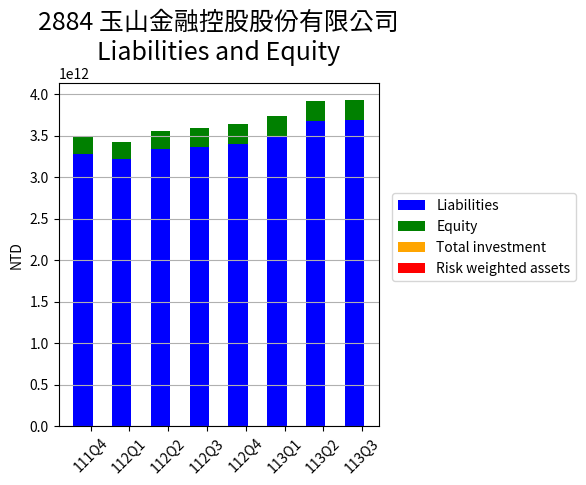

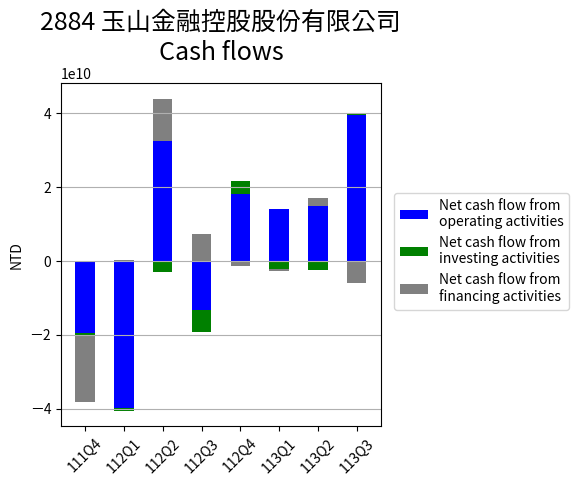

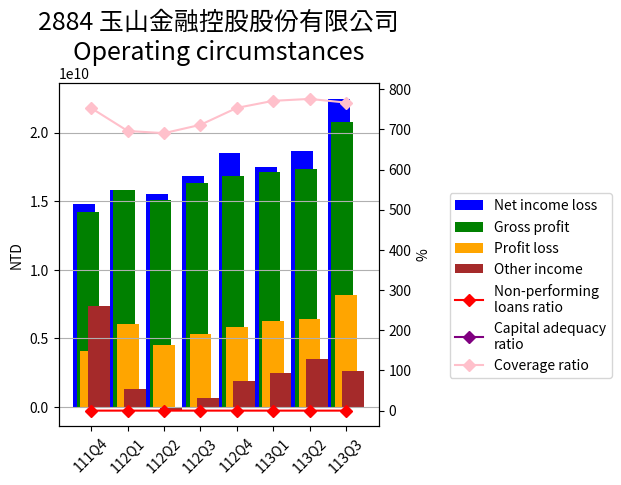

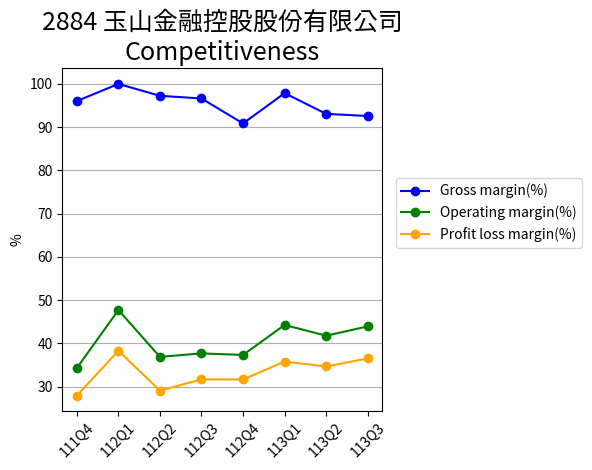

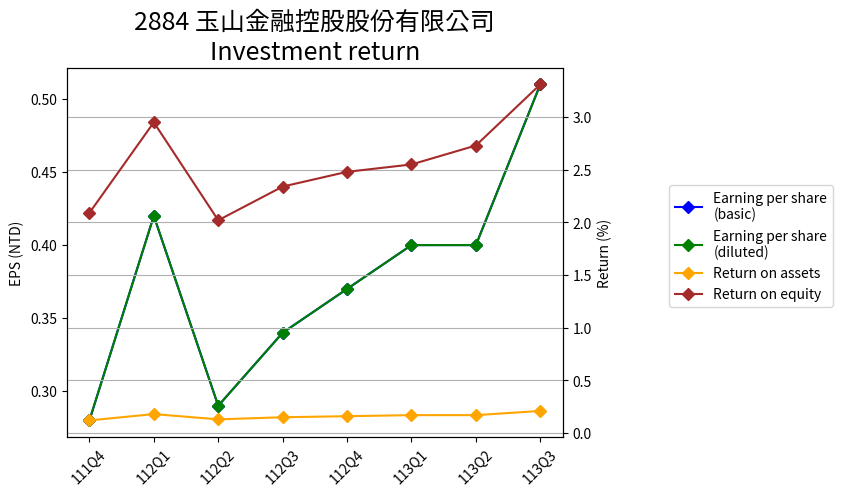

In [17]:
# Plotting test
test_list_inv_1=[
  {'Company': '2330 台灣積體電路製造股份有限公司', 'Quarter': '113Q3', 'Assets': 6165658176000.0, 'Inventories': 292883930000.0, 'Liabilities': 2143735885000.0, 'Equity': 4021922291000.0, 'BasicEarningsLossPerShare': 12.55, 'DilutedEarningsLossPerShare': 12.54, 'Revenue': 759692143000.0, 'GrossProfit': 439345666000.0, 'ProfitLossBeforeTax': 384186852000.0, 'ProfitLoss': 325080170000.0, 'ComprehensiveIncome': 304023892000.0, 'CashFlowsFromUsedInOperatingActivities': 391992467000.0, 'NetCashFlowsFromUsedInInvestingActivities': -195509921000.0, 'CashFlowsFromUsedInFinancingActivities': -83638287000.0, 'GrossMargin': 57.83, 'OperatingMargin': 50.57, 'ProfitLossMargin': 42.79, 'DaysSalesOfInventories': 333.71, 'ROA': 5.27, 'ROE': 8.08},
  {'Company': '2330 台灣積體電路製造股份有限公司', 'Quarter': '113Q2', 'Assets': 5982364014000.0, 'Inventories': 272490587000.0, 'Liabilities': 2162215809000.0, 'Equity': 3820148205000.0, 'BasicEarningsLossPerShare': 9.56, 'DilutedEarningsLossPerShare': 9.56, 'Revenue': 673510177000.0, 'GrossProfit': 358124478000.0, 'ProfitLossBeforeTax': 306310575000.0, 'ProfitLoss': 247661438000.0, 'ComprehensiveIncome': 261126037000.0, 'CashFlowsFromUsedInOperatingActivities': 377668210000.0, 'NetCashFlowsFromUsedInInvestingActivities': -197607330000.0, 'CashFlowsFromUsedInFinancingActivities': -90244583000.0, 'GrossMargin': 53.17, 'OperatingMargin': 45.48, 'ProfitLossMargin': 36.77, 'DaysSalesOfInventories': 315.36, 'ROA': 4.14, 'ROE': 6.48},
  {'Company': '2330 台灣積體電路製造股份有限公司', 'Quarter': '113Q1', 'Assets': 5787891082000.0, 'Inventories': 267123339000.0, 'Liabilities': 2122174828000.0, 'Equity': 3665716254000.0, 'BasicEarningsLossPerShare': 8.7, 'DilutedEarningsLossPerShare': 8.7, 'Revenue': 592644201000.0, 'GrossProfit': 314505269000.0, 'ProfitLossBeforeTax': 266543204000.0, 'ProfitLoss': 225221263000.0, 'ComprehensiveIncome': 266495211000.0, 'CashFlowsFromUsedInOperatingActivities': 436311108000.0, 'NetCashFlowsFromUsedInInvestingActivities': -159806991000.0, 'CashFlowsFromUsedInFinancingActivities': -71685617000.0, 'GrossMargin': 53.07, 'OperatingMargin': 44.98, 'ProfitLossMargin': 38.0, 'DaysSalesOfInventories': 350.54, 'ROA': 3.89, 'ROE': 6.14},
  {'Company': '2330 台灣積體電路製造股份有限公司', 'Quarter': '112Q4', 'Assets': 5532371215000.0, 'Inventories': 250997088000.0, 'Liabilities': 2049108368000.0, 'Equity': 3483262847000.0, 'BasicEarningsLossPerShare': 9.210000000000004, 'DilutedEarningsLossPerShare': 9.210000000000004, 'Revenue': 625528856000.0, 'GrossProfit': 331767925000.0, 'ProfitLossBeforeTax': 278280989000.0, 'ProfitLoss': 238306201000.0, 'ComprehensiveIncome': 201080001000.0, 'CashFlowsFromUsedInOperatingActivities': 394829347000.0, 'NetCashFlowsFromUsedInInvestingActivities': -132319502000.0, 'CashFlowsFromUsedInFinancingActivities': -75367133000.0, 'GrossMargin': 53.04, 'OperatingMargin': 44.49, 'ProfitLossMargin': 38.1, 'DaysSalesOfInventories': 311.87, 'ROA': 4.31, 'ROE': 6.84},
  {'Company': '2330 台灣積體電路製造股份有限公司', 'Quarter': '112Q3', 'Assets': 5484556381000.0, 'Inventories': 262090072000.0, 'Liabilities': 2111738274000.0, 'Equity': 3372818107000.0, 'BasicEarningsLossPerShare': 8.14, 'DilutedEarningsLossPerShare': 8.14, 'Revenue': 546732758000.0, 'GrossProfit': 296642464000.0, 'ProfitLossBeforeTax': 241940495000.0, 'ProfitLoss': 210795274000.0, 'ComprehensiveIncome': 236844499000.0, 'CashFlowsFromUsedInOperatingActivities': 294645276000.0, 'NetCashFlowsFromUsedInInvestingActivities': -242243223000.0, 'CashFlowsFromUsedInFinancingActivities': -38451204000.0, 'GrossMargin': 54.26, 'OperatingMargin': 44.25, 'ProfitLossMargin': 38.56, 'DaysSalesOfInventories': 382.51, 'ROA': 3.84, 'ROE': 6.25},
  {'Company': '2330 台灣積體電路製造股份有限公司', 'Quarter': '112Q2', 'Assets': 5149465045000.0, 'Inventories': 234332949000.0, 'Liabilities': 1943996846000.0, 'Equity': 3205468199000.0, 'BasicEarningsLossPerShare': 7.01, 'DilutedEarningsLossPerShare': 7.01, 'Revenue': 480841254000.0, 'GrossProfit': 260199847000.0, 'ProfitLossBeforeTax': 214674909000.0, 'ProfitLoss': 181717006000.0, 'ComprehensiveIncome': 187376110000.0, 'CashFlowsFromUsedInOperatingActivities': 167247979000.0, 'NetCashFlowsFromUsedInInvestingActivities': -259326076000.0, 'CashFlowsFromUsedInFinancingActivities': -26588885000.0, 'GrossMargin': 54.11, 'OperatingMargin': 44.65, 'ProfitLossMargin': 37.79, 'DaysSalesOfInventories': 387.65, 'ROA': 3.53, 'ROE': 5.67},
  {'Company': '2330 台灣積體電路製造股份有限公司', 'Quarter': '112Q1', 'Assets': 5045844348000.0, 'Inventories': 216067981000.0, 'Liabilities': 1952946750000.0, 'Equity': 3092897598000.0, 'BasicEarningsLossPerShare': 7.98, 'DilutedEarningsLossPerShare': 7.98, 'Revenue': 508632973000.0, 'GrossProfit': 286500392000.0, 'ProfitLossBeforeTax': 244274931000.0, 'ProfitLoss': 206949036000.0, 'ComprehensiveIncome': 203653263000.0, 'CashFlowsFromUsedInOperatingActivities': 385244745000.0, 'NetCashFlowsFromUsedInInvestingActivities': -272231795000.0, 'CashFlowsFromUsedInFinancingActivities': -64487030000.0, 'GrossMargin': 56.33, 'OperatingMargin': 48.03, 'ProfitLossMargin': 40.69, 'DaysSalesOfInventories': 355.03, 'ROA': 4.1, 'ROE': 6.69},
  {'Company': '2330 台灣積體電路製造股份有限公司', 'Quarter': '111Q4', 'Assets': 4964778878000.0, 'Inventories': 221149148000.0, 'Liabilities': 2004290011000.0, 'Equity': 2960488867000.0, 'BasicEarningsLossPerShare': 11.410000000000004, 'DilutedEarningsLossPerShare': 11.410000000000004, 'Revenue': 625531868000.0, 'GrossProfit': 389184929000.0, 'ProfitLossBeforeTax': 334669874000.0, 'ProfitLoss': 295878482000.0, 'ComprehensiveIncome': 279396526000.0, 'CashFlowsFromUsedInOperatingActivities': 486881904000.0, 'NetCashFlowsFromUsedInInvestingActivities': -342532013000.0, 'CashFlowsFromUsedInFinancingActivities': -69831545000.0, 'GrossMargin': 62.22, 'OperatingMargin': 53.5, 'ProfitLossMargin': 47.3, 'DaysSalesOfInventories': 341.53, 'ROA': 5.96, 'ROE': 9.99}
]

test_list_no_inv_1=[
  {'Company': '2884 玉山金融控股股份有限公司', 'Quarter': '113Q3', 'Assets': 3932144292000.0, 'Liabilities': 3684605961000.0, 'Equity': 247538331000.0, 'RiskWeightedAssets': np.nan, 'GrossLoans': 2246833743000.0, 'AmountOfNon-PerformingLoans': 3642742000.0, 'AllowanceForBadDebts-AssetQualityForBankSubsidiaries': 27926014000.0, 'TotalInvestment': np.nan, 'BasicEarningsLossPerShare': 0.51, 'DilutedEarningsLossPerShare': 0.51, 'NetIncomeLoss': 22464626000.0, 'OperatingExpense': 10935516000.0, 'ProfitLossBeforeTax': 9864821000.0, 'GrossProfit': 20800337000.0, 'ProfitLoss': 8199970000.0, 'ComprehensiveIncome': 10803977000.0, 'CashFlowsFromUsedInOperatingActivities': 39375945000.0, 'NetCashFlowsFromUsedInInvestingActivities': 763621000.0, 'CashFlowsFromUsedInFinancingActivities': -6041065000.0, 'GrossMargin': 92.59, 'OperatingMargin': 43.91, 'ProfitLossMargin': 36.5, 'NonPerformingLoansRatio': 0.16, 'CapitalAdequacyRatio': np.nan, 'CoverageRatio': 766.62, 'ROA': 0.21, 'ROE': 3.31},
  {'Company': '2884 玉山金融控股股份有限公司', 'Quarter': '113Q2', 'Assets': 3911417526000.0, 'Liabilities': 3674683172000.0, 'Equity': 236734354000.0, 'RiskWeightedAssets': np.nan, 'GrossLoans': 2183975856000.0, 'AmountOfNon-PerformingLoans': 3409991000.0, 'AllowanceForBadDebts-AssetQualityForBankSubsidiaries': 26451749000.0, 'TotalInvestment': np.nan, 'BasicEarningsLossPerShare': 0.4, 'DilutedEarningsLossPerShare': 0.4, 'NetIncomeLoss': 18646944000.0, 'OperatingExpense': 9570810000.0, 'ProfitLossBeforeTax': 7785261000.0, 'GrossProfit': 17356071000.0, 'ProfitLoss': 6456560000.0, 'ComprehensiveIncome': 9924164000.0, 'CashFlowsFromUsedInOperatingActivities': 14995609000.0, 'NetCashFlowsFromUsedInInvestingActivities': -2365960000.0, 'CashFlowsFromUsedInFinancingActivities': 2062394000.0, 'GrossMargin': 93.08, 'OperatingMargin': 41.75, 'ProfitLossMargin': 34.63, 'NonPerformingLoansRatio': 0.16, 'CapitalAdequacyRatio': np.nan, 'CoverageRatio': 775.71, 'ROA': 0.17, 'ROE': 2.73},
  {'Company': '2884 玉山金融控股股份有限公司', 'Quarter': '113Q1', 'Assets': 3734752361000.0, 'Liabilities': 3489129204000.0, 'Equity': 245623157000.0, 'RiskWeightedAssets': np.nan, 'GrossLoans': 2078312527000.0, 'AmountOfNon-PerformingLoans': 3275511000.0, 'AllowanceForBadDebts-AssetQualityForBankSubsidiaries': 25253028000.0, 'TotalInvestment': np.nan, 'BasicEarningsLossPerShare': 0.4, 'DilutedEarningsLossPerShare': 0.4, 'NetIncomeLoss': 17486529000.0, 'OperatingExpense': 9379757000.0, 'ProfitLossBeforeTax': 7735330000.0, 'GrossProfit': 17115087000.0, 'ProfitLoss': 6254267000.0, 'ComprehensiveIncome': 8730410000.0, 'CashFlowsFromUsedInOperatingActivities': 14118097000.0, 'NetCashFlowsFromUsedInInvestingActivities': -2299668000.0, 'CashFlowsFromUsedInFinancingActivities': -319780000.0, 'GrossMargin': 97.88, 'OperatingMargin': 44.24, 'ProfitLossMargin': 35.77, 'NonPerformingLoansRatio': 0.16, 'CapitalAdequacyRatio': np.nan, 'CoverageRatio': 770.96, 'ROA': 0.17, 'ROE': 2.55},
  {'Company': '2884 玉山金融控股股份有限公司', 'Quarter': '112Q4', 'Assets': 3638497500000.0, 'Liabilities': 3402073653000.0, 'Equity': 236423847000.0, 'RiskWeightedAssets': np.nan, 'GrossLoans': 2033444518000.0, 'AmountOfNon-PerformingLoans': 3316971000.0, 'AllowanceForBadDebts-AssetQualityForBankSubsidiaries': 24988652000.0, 'TotalInvestment': np.nan, 'BasicEarningsLossPerShare': 0.3699999999999999, 'DilutedEarningsLossPerShare': 0.3699999999999999, 'NetIncomeLoss': 18514087000.0, 'OperatingExpense': 9916070000.0, 'ProfitLossBeforeTax': 6905777000.0, 'GrossProfit': 16821847000.0, 'ProfitLoss': 5855761000.0, 'ComprehensiveIncome': 7728811000.0, 'CashFlowsFromUsedInOperatingActivities': 18039207000.0, 'NetCashFlowsFromUsedInInvestingActivities': 3508018000.0, 'CashFlowsFromUsedInFinancingActivities': -1460155000.0, 'GrossMargin': 90.86, 'OperatingMargin': 37.3, 'ProfitLossMargin': 31.63, 'NonPerformingLoansRatio': 0.16, 'CapitalAdequacyRatio': np.nan, 'CoverageRatio': 753.36, 'ROA': 0.16, 'ROE': 2.48},
  {'Company': '2884 玉山金融控股股份有限公司', 'Quarter': '112Q3', 'Assets': 3590762229000.0, 'Liabilities': 3362067193000.0, 'Equity': 228695036000.0, 'RiskWeightedAssets': np.nan, 'GrossLoans': 1973505867000.0, 'AmountOfNon-PerformingLoans': 3355366000.0, 'AllowanceForBadDebts-AssetQualityForBankSubsidiaries': 23865873000.0, 'TotalInvestment': np.nan, 'BasicEarningsLossPerShare': 0.34, 'DilutedEarningsLossPerShare': 0.34, 'NetIncomeLoss': 16877187000.0, 'OperatingExpense': 9953847000.0, 'ProfitLossBeforeTax': 6356180000.0, 'GrossProfit': 16310027000.0, 'ProfitLoss': 5342137000.0, 'ComprehensiveIncome': 5981209000.0, 'CashFlowsFromUsedInOperatingActivities': -13206234000.0, 'NetCashFlowsFromUsedInInvestingActivities': -5986057000.0, 'CashFlowsFromUsedInFinancingActivities': 7173039000.0, 'GrossMargin': 96.64, 'OperatingMargin': 37.66, 'ProfitLossMargin': 31.65, 'NonPerformingLoansRatio': 0.17, 'CapitalAdequacyRatio': np.nan, 'CoverageRatio': 711.27, 'ROA': 0.15, 'ROE': 2.34},
  {'Company': '2884 玉山金融控股股份有限公司', 'Quarter': '112Q2', 'Assets': 3557375872000.0, 'Liabilities': 3334649112000.0, 'Equity': 222726760000.0, 'RiskWeightedAssets': np.nan, 'GrossLoans': 1930530733000.0, 'AmountOfNon-PerformingLoans': 3374363000.0, 'AllowanceForBadDebts-AssetQualityForBankSubsidiaries': 23302306000.0, 'TotalInvestment': np.nan, 'BasicEarningsLossPerShare': 0.29, 'DilutedEarningsLossPerShare': 0.29, 'NetIncomeLoss': 15504087000.0, 'OperatingExpense': 9365537000.0, 'ProfitLossBeforeTax': 5714282000.0, 'GrossProfit': 15079819000.0, 'ProfitLoss': 4503283000.0, 'ComprehensiveIncome': 4243709000.0, 'CashFlowsFromUsedInOperatingActivities': 32421457000.0, 'NetCashFlowsFromUsedInInvestingActivities': -3113549000.0, 'CashFlowsFromUsedInFinancingActivities': 11440319000.0, 'GrossMargin': 97.26, 'OperatingMargin': 36.86, 'ProfitLossMargin': 29.05, 'NonPerformingLoansRatio': 0.17, 'CapitalAdequacyRatio': np.nan, 'CoverageRatio': 690.57, 'ROA': 0.13, 'ROE': 2.02},
  {'Company': '2884 玉山金融控股股份有限公司', 'Quarter': '112Q1', 'Assets': 3427271056000.0, 'Liabilities': 3222387658000.0, 'Equity': 204883398000.0, 'RiskWeightedAssets': np.nan, 'GrossLoans': 1896806611000.0, 'AmountOfNon-PerformingLoans': 3297798000.0, 'AllowanceForBadDebts-AssetQualityForBankSubsidiaries': 22949066000.0, 'TotalInvestment': np.nan, 'BasicEarningsLossPerShare': 0.42, 'DilutedEarningsLossPerShare': 0.42, 'NetIncomeLoss': 15800210000.0, 'OperatingExpense': 8266322000.0, 'ProfitLossBeforeTax': 7535772000.0, 'GrossProfit': 15802094000.0, 'ProfitLoss': 6046586000.0, 'ComprehensiveIncome': 7337784000.0, 'CashFlowsFromUsedInOperatingActivities': -39709472000.0, 'NetCashFlowsFromUsedInInvestingActivities': -836211000.0, 'CashFlowsFromUsedInFinancingActivities': 200910000.0, 'GrossMargin': 100.01, 'OperatingMargin': 47.69, 'ProfitLossMargin': 38.27, 'NonPerformingLoansRatio': 0.17, 'CapitalAdequacyRatio': np.nan, 'CoverageRatio': 695.89, 'ROA': 0.18, 'ROE': 2.95},
  {'Company': '2884 玉山金融控股股份有限公司', 'Quarter': '111Q4', 'Assets': 3479560474000.0, 'Liabilities': 3282469520000.0, 'Equity': 197090954000.0, 'RiskWeightedAssets': np.nan, 'GrossLoans': 1902436046000.0, 'AmountOfNon-PerformingLoans': 3126279000.0, 'AllowanceForBadDebts-AssetQualityForBankSubsidiaries': 23527267000.0, 'TotalInvestment': np.nan, 'BasicEarningsLossPerShare': 0.28000000000000014, 'DilutedEarningsLossPerShare': 0.28000000000000014, 'NetIncomeLoss': 14774126000.0, 'OperatingExpense': 9127735000.0, 'ProfitLossBeforeTax': 5060836000.0, 'GrossProfit': 14188571000.0, 'ProfitLoss': 4121008000.0, 'ComprehensiveIncome': 11513162000.0, 'CashFlowsFromUsedInOperatingActivities': -19576441000.0, 'NetCashFlowsFromUsedInInvestingActivities': -887873000.0, 'CashFlowsFromUsedInFinancingActivities': -17867596000.0, 'GrossMargin': 96.04, 'OperatingMargin': 34.25, 'ProfitLossMargin': 27.89, 'NonPerformingLoansRatio': 0.16, 'CapitalAdequacyRatio': np.nan, 'CoverageRatio': 752.56, 'ROA': 0.12, 'ROE': 2.09}
]
plot_results(test_list_no_inv_1)

## 主執行區

Taiwan Stock Analysis in real-time
請輸入台股代碼：1477
Get financial data from 公開資訊觀測站
開啟twse.com.tw
找到輸入框
輸入: 1477
開始搜尋
搜尋結果table數: 1
IFRSs後財報數量: 47
點開113Q3財報
	財報標題: 1477 聚陽實業股份有限公司<br>2024年第3季合併財務報告
點開113Q2財報
	財報標題: 1477 聚陽實業股份有限公司<br>2024年第2季合併財務報告
點開113Q1財報
	財報標題: 1477 聚陽實業股份有限公司<br>2024年第1季合併財務報告
點開112Q4財報
	財報標題: 1477 聚陽實業股份有限公司<br>2023年第4季合併財務報告
點開112Q3財報
	財報標題: 1477 聚陽實業股份有限公司<br>2023年第3季合併財務報告
點開112Q2財報
	財報標題: 1477 聚陽實業股份有限公司<br>2023年第2季合併財務報告
點開112Q1財報
	財報標題: 1477 聚陽實業股份有限公司<br>2023年第1季合併財務報告
點開111Q4財報
	財報標題: 1477 聚陽實業股份有限公司<br>2022年第4季合併財務報告
點開111Q3財報
	財報標題: 1477 聚陽實業股份有限公司<br>2022年第3季合併財務報告
開始處理財報...
	是否有存貨？ 是
	同時輸入的財報：113Q3與113Q2
開始處理財報...
	是否有存貨？ 是
	同時輸入的財報：113Q2與113Q1
開始處理財報...
	是否有存貨？ 是
	同時輸入的財報：113Q1與112Q4
開始處理財報...
	是否有存貨？ 是
	同時輸入的財報：112Q4與112Q3
開始處理財報...
	是否有存貨？ 是
	同時輸入的財報：112Q3與112Q2
開始處理財報...
	是否有存貨？ 是
	同時輸入的財報：112Q2與112Q1
開始處理財報...
	是否有存貨？ 是
	同時輸入的財報：112Q1與111Q4
開始處理財報...
	是否有存貨？ 是
	同時輸入的財報：111Q4與111Q3
{'Company': '1477 聚陽實業股份有限公司', 'Quarter': '113Q3', 'Assets': 233216520

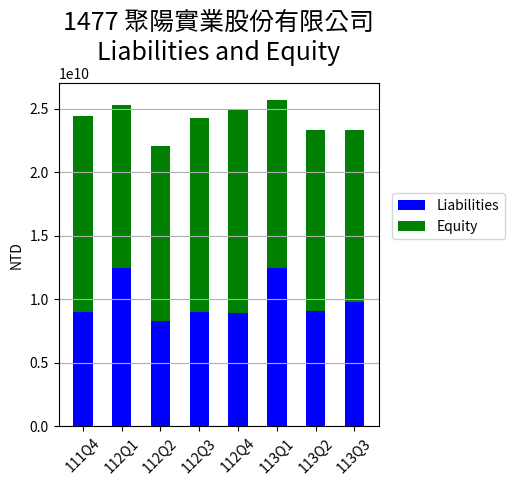

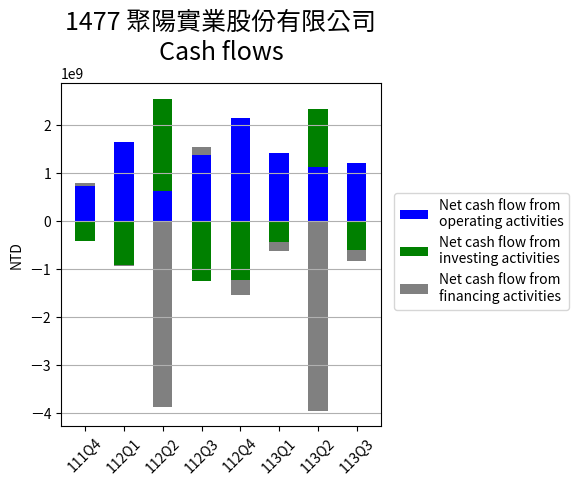

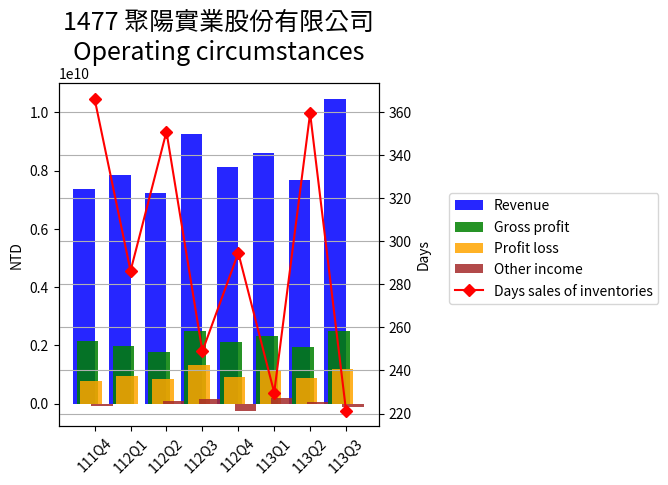

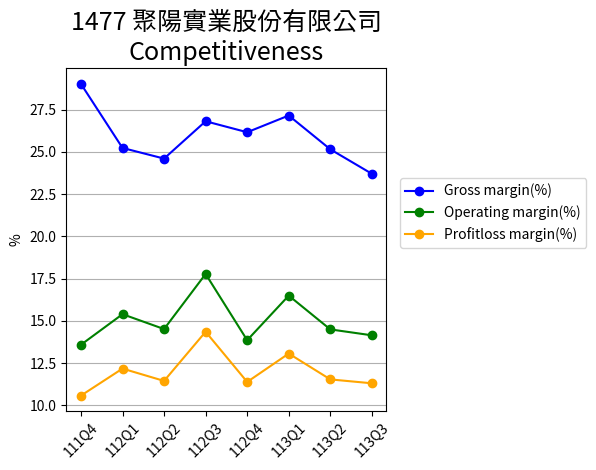

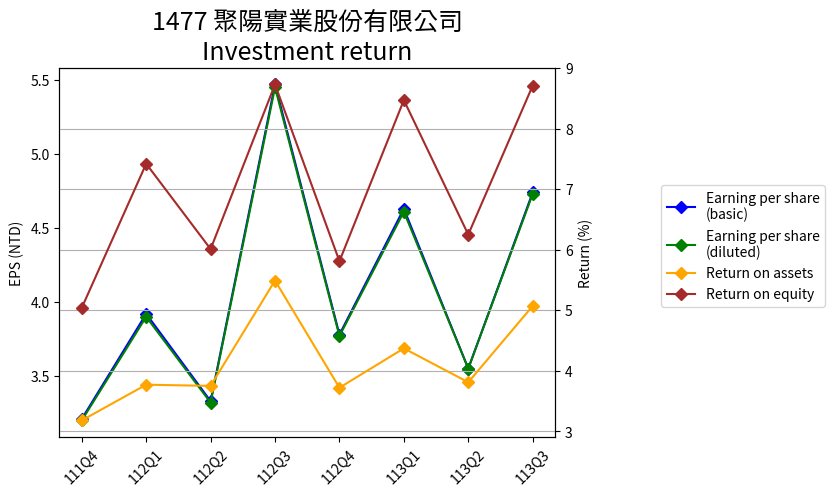

In [18]:
if __name__=="__main__":
  print("Taiwan Stock Analysis in real-time")
  stock_number=input('請輸入台股代碼：')
  await go_to_twse()

## 測試區

In [ ]:
ss="2330 台灣積體電路製造股份有限公司<br>2024年第3季合併財務報告"
rr=re.search(r'(.*)<br>',ss)
rr.groups()[0]

# (np.round(23/np.nan))
xx={"name":"Hello"}
yy={"tupleref":"TL"}
xx|yy

{'name': 'Hello', 'tupleref': 'TL'}

In [ ]:
tt='''<table style="width:90%">
					<tbody><tr><th colspan="5"><span class="zh">資產負債表</span><span class="en" style="display: none;">Balance Sheet</span></th></tr>
					<tr>
						<th><span class="zh">代號</span><span class="en" style="display: none;">Code</span></th>
						<th><span class="zh">會計項目</span><span class="en" style="display: none;">Accounting Title</span></th>
						<th><span class="zh">2024年9月30日</span><span class="en" style="display: none;">2024/9/30</span></th>
						<th><span class="zh">2023年12月31日</span><span class="en" style="display: none;">2023/12/31</span></th>
						<th><span class="zh">2023年9月30日</span><span class="en" style="display: none;">2023/9/30</span></th>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">資產</span><span class="en" style="display: none;">Assets</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　流動資產</span><span class="en" style="display: none;">　Current assets</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center">1100</td>
						<td><span class="zh">　　現金及約當現金</span><span class="en" style="display: none;">　　Cash and cash equivalents</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CashAndCashEquivalents" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,886,780,555</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CashAndCashEquivalents" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,465,427,753</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CashAndCashEquivalents" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,311,806,535</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1110</td>
						<td><span class="zh">　　透過損益按公允價值衡量之金融資產－流動</span><span class="en" style="display: none;">　　Current financial assets at fair value through profit or loss</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtFairValueThroughProfitOrLoss" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">971,386</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtFairValueThroughProfitOrLoss" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">924,636</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtFairValueThroughProfitOrLoss" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">378,526</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1120</td>
						<td><span class="zh">　　透過其他綜合損益按公允價值衡量之金融資產－流動</span><span class="en" style="display: none;">　　Current financial assets at fair value through other comprehensive income</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtFairValueThroughOtherComprehensiveIncome" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">189,649,314</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtFairValueThroughOtherComprehensiveIncome" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">154,530,830</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtFairValueThroughOtherComprehensiveIncome" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">154,838,390</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1136</td>
						<td><span class="zh">　　按攤銷後成本衡量之金融資產－流動</span><span class="en" style="display: none;">　　Current financial assets at amortised cost</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtAmortisedCost" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">90,197,355</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtAmortisedCost" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">66,761,221</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialAssetsAtAmortisedCost" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">84,261,089</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1139</td>
						<td><span class="zh">　　避險之金融資產－流動</span><span class="en" style="display: none;">　　Current financial assets for hedging</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:HedgingInstrumentAssets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,079</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:HedgingInstrumentAssets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">0</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:HedgingInstrumentAssets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">37,451</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1170</td>
						<td><span class="zh">　　應收帳款淨額</span><span class="en" style="display: none;">　　Accounts receivable, net</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:AccountsReceivableNet" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">249,570,573</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:AccountsReceivableNet" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">201,313,914</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:AccountsReceivableNet" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">222,467,653</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1180</td>
						<td><span class="zh">　　應收帳款－關係人淨額</span><span class="en" style="display: none;">　　Accounts receivable due from related parties, net</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:AccountsReceivableDuefromRelatedPartiesNet" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">403,379</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:AccountsReceivableDuefromRelatedPartiesNet" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">624,451</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:AccountsReceivableDuefromRelatedPartiesNet" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">356,257</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1210</td>
						<td><span class="zh">　　其他應收款－關係人</span><span class="en" style="display: none;">　　Other receivables due from related parties</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherReceivablesDueFromRelatedParties" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">74,477</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherReceivablesDueFromRelatedParties" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">71,871</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherReceivablesDueFromRelatedParties" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">82,363</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">130X</td>
						<td><span class="zh">　　存貨</span><span class="en" style="display: none;">　　Current inventories</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Inventories" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">292,883,930</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Inventories" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">250,997,088</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Inventories" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">262,090,072</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1470</td>
						<td><span class="zh">　　其他流動資產</span><span class="en" style="display: none;">　　Other current assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentAssets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">63,381,815</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentAssets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">53,381,146</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentAssets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">46,159,300</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1476</td>
						<td><span class="zh">　　　其他金融資產－流動</span><span class="en" style="display: none;">　　　Other current financial assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentFinancialAssets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">35,301,765</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentFinancialAssets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">27,158,766</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentFinancialAssets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">26,938,240</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1479</td>
						<td><span class="zh">　　　其他流動資產－其他</span><span class="en" style="display: none;">　　　Other current assets, others</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherCurrentAssetsOthers" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">28,080,050</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherCurrentAssetsOthers" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">26,222,380</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherCurrentAssetsOthers" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">19,221,060</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">11XX</td>
						<td><span class="zh">　　流動資產合計</span><span class="en" style="display: none;">　　Total current assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentAssets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,773,913,863</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentAssets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,194,032,910</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentAssets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,082,477,636</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　非流動資產</span><span class="en" style="display: none;">　Non-current assets</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center">1510</td>
						<td><span class="zh">　　透過損益按公允價值衡量之金融資產－非流動</span><span class="en" style="display: none;">　　Non-current financial assets at fair value through profit or loss</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtFairValueThroughProfitOrLoss" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">14,594,649</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtFairValueThroughProfitOrLoss" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">13,417,457</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtFairValueThroughProfitOrLoss" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">111,637</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1517</td>
						<td><span class="zh">　　透過其他綜合損益按公允價值衡量之金融資產－非流動</span><span class="en" style="display: none;">　　Non-current financial assets at fair value through other comprehensive income</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtFairValueThroughOtherComprehensiveIncome" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">7,502,973</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtFairValueThroughOtherComprehensiveIncome" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">7,208,655</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtFairValueThroughOtherComprehensiveIncome" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">7,933,799</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1535</td>
						<td><span class="zh">　　按攤銷後成本衡量之金融資產－非流動</span><span class="en" style="display: none;">　　Non-current financial assets at amortised cost</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtAmortisedCost" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">74,266,804</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtAmortisedCost" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">79,199,367</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinancialAssetsAtAmortisedCost" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">79,379,651</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1550</td>
						<td><span class="zh">　　採用權益法之投資</span><span class="en" style="display: none;">　　Investments accounted for using equity method</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:InvestmentAccountedForUsingEquityMethod" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">30,967,916</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:InvestmentAccountedForUsingEquityMethod" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">29,616,638</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:InvestmentAccountedForUsingEquityMethod" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">28,921,558</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1600</td>
						<td><span class="zh">　　不動產、廠房及設備</span><span class="en" style="display: none;">　　Property, plant and equipment</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:PropertyPlantAndEquipment" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,071,599,327</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:PropertyPlantAndEquipment" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,064,474,984</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:PropertyPlantAndEquipment" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,132,664,367</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1755</td>
						<td><span class="zh">　　使用權資產</span><span class="en" style="display: none;">　　Right-of-use assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:RightofuseAssets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">39,698,749</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:RightofuseAssets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">40,424,830</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:RightofuseAssets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">41,254,711</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1780</td>
						<td><span class="zh">　　無形資產</span><span class="en" style="display: none;">　　Intangible assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:IntangibleAssetsAndGoodwill" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">22,083,031</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:IntangibleAssetsAndGoodwill" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">22,766,744</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:IntangibleAssetsAndGoodwill" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">23,410,569</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1840</td>
						<td><span class="zh">　　遞延所得稅資產</span><span class="en" style="display: none;">　　Deferred tax assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:DeferredTaxAssets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">65,944,214</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:DeferredTaxAssets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">64,175,787</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:DeferredTaxAssets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">71,030,144</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1900</td>
						<td><span class="zh">　　其他非流動資產</span><span class="en" style="display: none;">　　Other non-current assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherNoncurrentAssets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">65,086,650</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherNoncurrentAssets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">17,053,843</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherNoncurrentAssets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">17,372,309</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1920</td>
						<td><span class="zh">　　　存出保證金</span><span class="en" style="display: none;">　　　Guarantee deposits paid</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:GuaranteeDepositsPaid" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">4,483,344</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:GuaranteeDepositsPaid" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">7,044,420</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:GuaranteeDepositsPaid" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,388,839</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1990</td>
						<td><span class="zh">　　　其他非流動資產－其他</span><span class="en" style="display: none;">　　　Other non-current assets, others</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherNoncurrentAssetsOthers" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">60,603,306</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherNoncurrentAssetsOthers" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">10,009,423</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherNoncurrentAssetsOthers" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,983,470</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">15XX</td>
						<td><span class="zh">　　非流動資產合計</span><span class="en" style="display: none;">　　Total non-current assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentAssets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,391,744,313</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentAssets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,338,338,305</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentAssets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,402,078,745</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">1XXX</td>
						<td><span class="zh">　資產總計</span><span class="en" style="display: none;">　Total assets</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Assets" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">6,165,658,176</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Assets" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">5,532,371,215</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Assets" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">5,484,556,381</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">負債及權益</span><span class="en" style="display: none;">Liabilities and equity</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　負債</span><span class="en" style="display: none;">　Liabilities</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　　流動負債</span><span class="en" style="display: none;">　　Current liabilities</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center">2120</td>
						<td><span class="zh">　　　透過損益按公允價值衡量之金融負債－流動</span><span class="en" style="display: none;">　　　Current financial liabilities at fair value through profit or loss</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialLiabilitiesAtFairValueThroughProfitOrLoss" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">34,277</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialLiabilitiesAtFairValueThroughProfitOrLoss" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">121,412</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentFinancialLiabilitiesAtFairValueThroughProfitOrLoss" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">132,768</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2126</td>
						<td><span class="zh">　　　避險之金融負債－流動</span><span class="en" style="display: none;">　　　Current financial liabilities for hedging</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:HedgingInstrumentLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,875</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:HedgingInstrumentLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">27,334,164</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:HedgingInstrumentLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">26,879,550</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2170</td>
						<td><span class="zh">　　　應付帳款</span><span class="en" style="display: none;">　　　Accounts payable</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:TradeAndOtherCurrentPayablesToTradeSuppliers" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">69,134,197</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:TradeAndOtherCurrentPayablesToTradeSuppliers" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">55,726,757</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:TradeAndOtherCurrentPayablesToTradeSuppliers" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">52,150,883</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2180</td>
						<td><span class="zh">　　　應付帳款－關係人</span><span class="en" style="display: none;">　　　Accounts payable to related parties</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:TradeAndOtherCurrentPayablesToRelatedParties" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,685,850</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:TradeAndOtherCurrentPayablesToRelatedParties" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,566,300</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:TradeAndOtherCurrentPayablesToRelatedParties" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,621,423</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2200</td>
						<td><span class="zh">　　　其他應付款</span><span class="en" style="display: none;">　　　Other payables</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentPayables" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">419,701,871</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentPayables" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">423,960,584</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentPayables" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">452,806,783</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2201</td>
						<td><span class="zh">　　　　應付薪資</span><span class="en" style="display: none;">　　　　Wages and salaries payable</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:WagesAndSalariesPayable" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">37,714,425</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:WagesAndSalariesPayable" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">33,200,563</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:WagesAndSalariesPayable" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">28,657,288</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2206</td>
						<td><span class="zh">　　　　應付員工紅利</span><span class="en" style="display: none;">　　　　Employee bonus payable</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:EmployeeBonusPayable" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">49,175,098</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:EmployeeBonusPayable" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">50,164,989</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:EmployeeBonusPayable" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">37,312,085</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2207</td>
						<td><span class="zh">　　　　應付董監事酬勞</span><span class="en" style="display: none;">　　　　Compensation due to directors and supervisors</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CompensationDueToDirectorsAndSupervisors" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">224,225</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CompensationDueToDirectorsAndSupervisors" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">551,955</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CompensationDueToDirectorsAndSupervisors" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">396,118</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2213</td>
						<td><span class="zh">　　　　應付設備款</span><span class="en" style="display: none;">　　　　Payable on machinery and equipment</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:PayableOnMachineryAndEquipment" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">125,132,085</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:PayableOnMachineryAndEquipment" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">171,484,616</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:PayableOnMachineryAndEquipment" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">230,848,866</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2216</td>
						<td><span class="zh">　　　　應付股利</span><span class="en" style="display: none;">　　　　Dividends payable, non-cash assets distributions</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentDividendPayables" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">207,456,038</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentDividendPayables" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">168,558,461</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentDividendPayables" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">155,592,426</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2230</td>
						<td><span class="zh">　　　本期所得稅負債</span><span class="en" style="display: none;">　　　Current tax liabilities</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentTaxLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">77,422,729</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentTaxLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">98,912,902</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentTaxLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">102,953,391</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2300</td>
						<td><span class="zh">　　　其他流動負債</span><span class="en" style="display: none;">　　　Other current liabilities</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">512,418,300</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">305,961,197</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherCurrentLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">333,490,018</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2320</td>
						<td><span class="zh">　　　　一年或一營業週期內到期長期負債</span><span class="en" style="display: none;">　　　　Long-term liabilities, current portion</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:LongtermLiabilitiesCurrentPortion" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">58,804,983</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:LongtermLiabilitiesCurrentPortion" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">9,293,266</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:LongtermLiabilitiesCurrentPortion" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">7,420,132</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2399</td>
						<td><span class="zh">　　　　其他流動負債－其他</span><span class="en" style="display: none;">　　　　Other current liabilities, others</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherCurrentLiabilitiesOthers" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">453,613,317</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherCurrentLiabilitiesOthers" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">296,667,931</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherCurrentLiabilitiesOthers" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">326,069,886</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">21XX</td>
						<td><span class="zh">　　　流動負債合計</span><span class="en" style="display: none;">　　　Total current liabilities</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,080,399,099</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">913,583,316</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CurrentLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">970,034,816</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　　非流動負債</span><span class="en" style="display: none;">　　Non-current liabilities</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center">2530</td>
						<td><span class="zh">　　　應付公司債</span><span class="en" style="display: none;">　　　Bonds payable</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentPortionOfNoncurrentBondsIssued" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">909,703,588</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentPortionOfNoncurrentBondsIssued" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">913,899,843</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentPortionOfNoncurrentBondsIssued" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">932,479,423</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2540</td>
						<td><span class="zh">　　　長期借款</span><span class="en" style="display: none;">　　　Non-current portion of non-current borrowings</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:LongtermBorrowings" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">26,459,677</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:LongtermBorrowings" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">4,382,965</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:LongtermBorrowings" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">5,013,050</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2541</td>
						<td><span class="zh">　　　　銀行長期借款</span><span class="en" style="display: none;">　　　　Long-term bank loans</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentPortionOfNoncurrentLoansReceived" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">26,459,677</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentPortionOfNoncurrentLoansReceived" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">4,382,965</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentPortionOfNoncurrentLoansReceived" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">5,013,050</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2570</td>
						<td><span class="zh">　　　遞延所得稅負債</span><span class="en" style="display: none;">　　　Deferred tax liabilities</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:DeferredTaxLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">61,376</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:DeferredTaxLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">53,856</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:DeferredTaxLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">212,549</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2580</td>
						<td><span class="zh">　　　租賃負債－非流動</span><span class="en" style="display: none;">　　　Non-current lease liabilities</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinanceLeaseLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">28,208,721</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinanceLeaseLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">28,681,835</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentFinanceLeaseLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">29,415,325</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2600</td>
						<td><span class="zh">　　　其他非流動負債</span><span class="en" style="display: none;">　　　Other non-current liabilities</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherNoncurrentLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">98,903,424</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherNoncurrentLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">188,506,553</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherNoncurrentLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">174,583,111</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2640</td>
						<td><span class="zh">　　　　淨確定福利負債-非流動</span><span class="en" style="display: none;">　　　　Net defined benefit liability, non-current</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentRecognisedLiabilitiesDefinedBenefitPlan" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">7,704,373</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentRecognisedLiabilitiesDefinedBenefitPlan" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">9,257,224</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentRecognisedLiabilitiesDefinedBenefitPlan" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,615,678</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2645</td>
						<td><span class="zh">　　　　存入保證金</span><span class="en" style="display: none;">　　　　Guarantee deposits received</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:GuaranteeDepositsReceived" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">914,462</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:GuaranteeDepositsReceived" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">923,164</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:GuaranteeDepositsReceived" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">983,928</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2670</td>
						<td><span class="zh">　　　　其他非流動負債－其他</span><span class="en" style="display: none;">　　　　Other non-current liabilities, others</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherNoncurrentLiabilitiesOthers" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">90,284,589</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherNoncurrentLiabilitiesOthers" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">178,326,165</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OtherNoncurrentLiabilitiesOthers" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">164,983,505</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">25XX</td>
						<td><span class="zh">　　　非流動負債合計</span><span class="en" style="display: none;">　　　Total non-current liabilities</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,063,336,786</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,135,525,052</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncurrentLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">1,141,703,458</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">2XXX</td>
						<td><span class="zh">　　負債總計</span><span class="en" style="display: none;">　　Total liabilities</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Liabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,143,735,885</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Liabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,049,108,368</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Liabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,111,738,274</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　權益</span><span class="en" style="display: none;">　Equity</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　　歸屬於母公司業主之權益</span><span class="en" style="display: none;">　　Equity attributable to owners of parent</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　　　股本</span><span class="en" style="display: none;">　　　Share capital</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center">3110</td>
						<td><span class="zh">　　　　普通股股本</span><span class="en" style="display: none;">　　　　Ordinary share</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OrdinaryShare" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">259,327,332</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OrdinaryShare" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">259,320,710</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:OrdinaryShare" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">259,320,710</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3100</td>
						<td><span class="zh">　　　　股本合計</span><span class="en" style="display: none;">　　　　Total Share Capital</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:IssuedCapital" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">259,327,332</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:IssuedCapital" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">259,320,710</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:IssuedCapital" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">259,320,710</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　　　資本公積</span><span class="en" style="display: none;">　　　Capital surplus</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center">3210</td>
						<td><span class="zh">　　　　資本公積－發行溢價</span><span class="en" style="display: none;">　　　　Capital surplus, additional paid-in capital</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:AdditionalPaidinCapital" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">33,700,961</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:AdditionalPaidinCapital" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">33,299,225</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:AdditionalPaidinCapital" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">33,299,225</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3211</td>
						<td><span class="zh">　　　　　資本公積－普通股股票溢價</span><span class="en" style="display: none;">　　　　　Capital surplus, additional paid-in capital arising from ordinary share</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusAdditionalPaidInCapitalArisingFromOrdinaryShare" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">24,809,704</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusAdditionalPaidInCapitalArisingFromOrdinaryShare" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">24,406,854</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusAdditionalPaidInCapitalArisingFromOrdinaryShare" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">24,406,854</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3213</td>
						<td><span class="zh">　　　　　資本公積－轉換公司債轉換溢價</span><span class="en" style="display: none;">　　　　　Capital surplus, additional paid-in capital arising from bond conversion</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusAdditionalPaidInCapitalArisingFromBondConversion" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,891,257</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusAdditionalPaidInCapitalArisingFromBondConversion" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,892,371</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusAdditionalPaidInCapitalArisingFromBondConversion" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,892,371</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3230</td>
						<td><span class="zh">　　　　資本公積－實際取得或處分子公司股權價格與帳面價值差額</span><span class="en" style="display: none;">　　　　Capital surplus, difference between consideration and carrying amount of subsidiaries acquired or disposed</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDifferenceBetweenConsiderationAndCarryingAmountOfSubsidiariesAcquiredOrDisposed" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,411,566</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDifferenceBetweenConsiderationAndCarryingAmountOfSubsidiariesAcquiredOrDisposed" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,406,282</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDifferenceBetweenConsiderationAndCarryingAmountOfSubsidiariesAcquiredOrDisposed" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,406,282</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3235</td>
						<td><span class="zh">　　　　資本公積－認列對子公司所有權權益變動數</span><span class="en" style="display: none;">　　　　Capital Surplus, changes in ownership interests in subsidiaries</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusChangesInOwnershipInterestsInSubsidiaries" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">4,113,816</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusChangesInOwnershipInterestsInSubsidiaries" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">4,199,936</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusChangesInOwnershipInterestsInSubsidiaries" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">4,210,955</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3250</td>
						<td><span class="zh">　　　　資本公積－受贈資產</span><span class="en" style="display: none;">　　　　Capital surplus, donated assets received</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDonatedAssetsReceived" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">81,368</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDonatedAssetsReceived" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">81,368</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDonatedAssetsReceived" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">64,955</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3251</td>
						<td><span class="zh">　　　　　資本公積－受領股東贈與</span><span class="en" style="display: none;">　　　　　Capital surplus, donated assets received from shareholder</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDonatedAssetsReceivedFromShareholder" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">11,275</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDonatedAssetsReceivedFromShareholder" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">11,275</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusDonatedAssetsReceivedFromShareholder" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">11,275</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3252</td>
						<td><span class="zh">　　　　　資本公積－其他受贈資產</span><span class="en" style="display: none;">　　　　　Capital surplus, other donated assets received</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusOtherDonatedAssetsReceived" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">70,093</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusOtherDonatedAssetsReceived" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">70,093</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusOtherDonatedAssetsReceived" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">53,680</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3260</td>
						<td><span class="zh">　　　　資本公積－採用權益法認列關聯企業及合資股權淨值之變動數</span><span class="en" style="display: none;">　　　　Capital surplus, changes in equity of associates and joint ventures accounted for using equity method</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusChangesInEquityOfAssociatesAndJointVenturesAccountedForUsingEquityMethod" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">305,828</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusChangesInEquityOfAssociatesAndJointVenturesAccountedForUsingEquityMethod" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">302,396</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusChangesInEquityOfAssociatesAndJointVenturesAccountedForUsingEquityMethod" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">310,627</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3270</td>
						<td><span class="zh">　　　　資本公積－合併溢額</span><span class="en" style="display: none;">　　　　Capital surplus, net assets from merger</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:MergerReserve" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">22,800,434</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:MergerReserve" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">22,803,291</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:MergerReserve" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">22,803,291</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3273</td>
						<td><span class="zh">　　　　資本公積－限制員工權利股票</span><span class="en" style="display: none;">　　　　Capital Surplus, restricted stock</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusRestrictedStock" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,976,199</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusRestrictedStock" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">783,883</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:CapitalSurplusRestrictedStock" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">783,883</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3200</td>
						<td><span class="zh">　　　　資本公積合計</span><span class="en" style="display: none;">　　　　Total capital surplus</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CapitalReserve" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">72,390,172</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CapitalReserve" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">69,876,381</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:CapitalReserve" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">69,879,218</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　　　保留盈餘</span><span class="en" style="display: none;">　　　Retained earnings</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center">3310</td>
						<td><span class="zh">　　　　法定盈餘公積</span><span class="en" style="display: none;">　　　　Legal reserve</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:StatutoryReserve" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">311,146,899</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:StatutoryReserve" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">311,146,899</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:StatutoryReserve" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">311,146,899</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3320</td>
						<td><span class="zh">　　　　特別盈餘公積</span><span class="en" style="display: none;">　　　　Special reserve</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:SpecialReserve" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">0</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:SpecialReserve" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">0</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:SpecialReserve" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">17,228,363</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3350</td>
						<td><span class="zh">　　　　未分配盈餘（或待彌補虧損）</span><span class="en" style="display: none;">　　　　Unappropriated retained earnings (accumulated deficit)</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:UnappropriatedRetainedEarningsAaccumulatedDeficit" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,346,232,342</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:UnappropriatedRetainedEarningsAaccumulatedDeficit" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,846,883,893</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:UnappropriatedRetainedEarningsAaccumulatedDeficit" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">2,682,157,537</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3300</td>
						<td><span class="zh">　　　　保留盈餘合計</span><span class="en" style="display: none;">　　　　Total retained earnings</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:RetainedEarnings" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,657,379,241</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:RetainedEarnings" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,158,030,792</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:RetainedEarnings" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,010,532,799</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center"></td>
						<td><span class="zh">　　　其他權益</span><span class="en" style="display: none;">　　　Other equity interest</span></td>
						<td class="amt"></td>
						<td class="amt"></td>
						<td class="amt"></td>
					</tr>
					<tr>
						<td style="text-align:center">3400</td>
						<td><span class="zh">　　　　其他權益合計</span><span class="en" style="display: none;">　　　　Total other equity interest</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherEquityInterest" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">922,408</ix:nonfraction> </pre></td>
						<td class="amt"><pre>(<ix:nonfraction name="ifrs-full:OtherEquityInterest" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" sign="-" decimals="-3" unitref="TWD">28,314,256</ix:nonfraction>)</pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:OtherEquityInterest" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">8,616,930</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3500</td>
						<td><span class="zh">　　　庫藏股票</span><span class="en" style="display: none;">　　　Treasury shares</span></td>
						<td class="amt"><pre>(<ix:nonfraction name="ifrs-full:TreasuryShares" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">0</ix:nonfraction>)</pre></td>
						<td class="amt"><pre>(<ix:nonfraction name="ifrs-full:TreasuryShares" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">0</ix:nonfraction>)</pre></td>
						<td class="amt"><pre>(<ix:nonfraction name="ifrs-full:TreasuryShares" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">0</ix:nonfraction>)</pre></td>
					</tr>
					<tr>
						<td style="text-align:center">31XX</td>
						<td><span class="zh">　　　歸屬於母公司業主之權益合計</span><span class="en" style="display: none;">　　　Total equity attributable to owners of parent</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:EquityAttributableToOwnersOfParent" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,990,019,153</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:EquityAttributableToOwnersOfParent" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,458,913,627</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:EquityAttributableToOwnersOfParent" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,348,349,657</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">36XX</td>
						<td><span class="zh">　　非控制權益</span><span class="en" style="display: none;">　　Non-controlling interests</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncontrollingInterests" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">31,903,138</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncontrollingInterests" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">24,349,220</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:NoncontrollingInterests" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">24,468,450</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3XXX</td>
						<td><span class="zh">　　權益總額</span><span class="en" style="display: none;">　　Total equity</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Equity" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">4,021,922,291</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Equity" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,483,262,847</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:Equity" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">3,372,818,107</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3X2X</td>
						<td><span class="zh">　負債及權益總計</span><span class="en" style="display: none;">　Total liabilities and equity</span></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:EquityAndLiabilities" contextref="AsOf20240930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">6,165,658,176</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:EquityAndLiabilities" contextref="AsOf20231231" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">5,532,371,215</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="ifrs-full:EquityAndLiabilities" contextref="AsOf20230930" format="ixt:numdotdecimal" scale="3" decimals="-3" unitref="TWD">5,484,556,381</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3998</td>
						<td><span class="zh">　預收股款（權益項下）之約當發行股數</span><span class="en" style="display: none;">　Equivalent issue shares of advance receipts for ordinary share</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:EquivalentIssueSharesOfAdvanceReceiptsForOrdinaryShare" contextref="AsOf20240930" format="ixt:numdotdecimal" decimals="0" unitref="Shares">0</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:EquivalentIssueSharesOfAdvanceReceiptsForOrdinaryShare" contextref="AsOf20231231" format="ixt:numdotdecimal" decimals="0" unitref="Shares">0</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:EquivalentIssueSharesOfAdvanceReceiptsForOrdinaryShare" contextref="AsOf20230930" format="ixt:numdotdecimal" decimals="0" unitref="Shares">0</ix:nonfraction> </pre></td>
					</tr>
					<tr>
						<td style="text-align:center">3999</td>
						<td><span class="zh">　母公司暨子公司所持有之母公司庫藏股股數（單位：股）</span><span class="en" style="display: none;">　Number of shares in entity held by entity and by its subsidiaries</span></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:NumberOfSharesInEntityHeldByEntityAndByItsSubsidiaries" contextref="AsOf20240930" format="ixt:numdotdecimal" decimals="0" unitref="Shares">0</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:NumberOfSharesInEntityHeldByEntityAndByItsSubsidiaries" contextref="AsOf20231231" format="ixt:numdotdecimal" decimals="0" unitref="Shares">0</ix:nonfraction> </pre></td>
						<td class="amt"><pre><ix:nonfraction name="tifrs-bsci-ci:NumberOfSharesInEntityHeldByEntityAndByItsSubsidiaries" contextref="AsOf20230930" format="ixt:numdotdecimal" decimals="0" unitref="Shares">0</ix:nonfraction> </pre></td>
					</tr>
				</tbody></table>'''
soupp=BS(tt,'html.parser')
print(type(soupp))

inventory=soupp.find(lambda tag:tag.name=="tr" and any([True if re.search('存貨',c.text) else False for c in tag.contents]))
print(inventory)

<class 'bs4.BeautifulSoup'>
<tr>
<td style="text-align:center">130X</td>
<td><span class="zh">　　存貨</span><span class="en" style="display: none;">　　Current inventories</span></td>
<td class="amt"><pre><ix:nonfraction contextref="AsOf20240930" decimals="-3" format="ixt:numdotdecimal" name="ifrs-full:Inventories" scale="3" unitref="TWD">292,883,930</ix:nonfraction> </pre></td>
<td class="amt"><pre><ix:nonfraction contextref="AsOf20231231" decimals="-3" format="ixt:numdotdecimal" name="ifrs-full:Inventories" scale="3" unitref="TWD">250,997,088</ix:nonfraction> </pre></td>
<td class="amt"><pre><ix:nonfraction contextref="AsOf20230930" decimals="-3" format="ixt:numdotdecimal" name="ifrs-full:Inventories" scale="3" unitref="TWD">262,090,072</ix:nonfraction> </pre></td>
</tr>


In [ ]:
<div id="BalanceSheet"></div>